# FINBERT SENTIMENT PIPELINE

In [1]:
import os
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor"

PROCESSED_FILE = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "aapl_features_with_target.parquet")

print("=" * 75)
print("NORTHGATE AI — FINBERT SENTIMENT PIPELINE")
print("=" * 75)

print("\nPython:")
print(sys.version)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProcessed dataset:")
print(PROCESSED_FILE)

print("\nDataset exists:", os.path.exists(PROCESSED_FILE))

if not os.path.exists(PROCESSED_FILE):
    raise FileNotFoundError(
        "Processed dataset not found. Check PROJECT_ROOT.")

NORTHGATE AI — FINBERT SENTIMENT PIPELINE

Python:
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]

Project root:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor

Processed dataset:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_target.parquet

Dataset exists: True


In [2]:
# Load processed dataset

df_sentiment = pd.read_parquet(PROCESSED_FILE)

print("\nDataset loaded successfully.")
print("Shape:", df_sentiment.shape)

print("\nDate range:")
print(
    df_sentiment["date"].min(),
    "→",
    df_sentiment["date"].max())

print("\nColumns available:", len(df_sentiment.columns))

print("\nRequired target columns:")
print(
    "future_return_5d:",
    "future_return_5d" in df_sentiment.columns)

print(
    "target:",
    "target" in df_sentiment.columns)

print("\nTarget missing values:")
print(
    df_sentiment[
        ["future_return_5d", "target"]
    ].isna().sum())

print("\nFirst 5 rows:")
display(
    df_sentiment[
        ["date", "future_return_5d", "target"]
    ].head())


Dataset loaded successfully.
Shape: (2931, 291)

Date range:
2015-01-02 00:00:00 → 2026-08-28 00:00:00

Columns available: 291

Required target columns:
future_return_5d: True
target: True

Target missing values:
future_return_5d    0
target              0
dtype: int64

First 5 rows:


,date,future_return_5d,target
0,2015-01-02,0.024513,1
1,2015-01-05,0.028235,1
2,2015-01-06,0.037267,1
3,2015-01-07,0.019026,1
4,2015-01-08,-0.045312,0


In [4]:
#  SEARCH PROJECT FOR NEWS / SENTIMENT DATA

import os

PROJECT_ROOT = r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor"

keywords = [
    "news",
    "headline",
    "sentiment",
    "finbert",
    "article"]

matches = []

for root, dirs, files in os.walk(PROJECT_ROOT):

    # Skip heavy / irrelevant folders
    dirs[:] = [
        d for d in dirs
        if d not in {
            ".git",
            "__pycache__",
            ".ipynb_checkpoints",
            "node_modules"}]

    for filename in files:

        lower_name = filename.lower()

        if any(keyword in lower_name for keyword in keywords):

            matches.append(
                os.path.join(root, filename))

print()
print("NEWS / SENTIMENT DATA SEARCH")
print()

if matches:

    print(f"\nFound {len(matches)} matching files:\n")

    for path in matches:
        print(path)

else:

    print("\nNo existing news/sentiment files found.")


NEWS / SENTIMENT DATA SEARCH


Found 1 matching files:

C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks\05_Sentiment_FinBERT.ipynb


In [5]:
# Check whether FinBERT / Transformers are already installed

import importlib.util

packages = {
    "transformers": "transformers",
    "torch": "torch",
    "pandas": "pandas",
    "numpy": "numpy",}

for name, module in packages.items():
    installed = importlib.util.find_spec(module) is not None
    print(f"{name:<15} : {'INSTALLED' if installed else 'NOT INSTALLED'}")

transformers    : NOT INSTALLED
torch           : INSTALLED
pandas          : INSTALLED
numpy           : INSTALLED


In [6]:
%pip install -U transformers

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 4.1 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.3 MB 3.7 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.3 MB 3.8 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.3 MB 4.0 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.3 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.3 MB 4.0 MB/s eta 0:00:02
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from transformers import pipeline

print("Loading FinBERT...")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert")

test_headlines = [
    "Apple reports strong quarterly earnings and raises its revenue outlook.",
    "Apple shares fall after disappointing sales guidance."]

for headline in test_headlines:
    result = finbert(headline)
    print(f"\nHeadline: {headline}")
    print("FinBERT:", result)

Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11218.90it/s]



Headline: Apple reports strong quarterly earnings and raises its revenue outlook.
FinBERT: [{'label': 'positive', 'score': 0.9510751962661743}]

Headline: Apple shares fall after disappointing sales guidance.
FinBERT: [{'label': 'negative', 'score': 0.9594288468360901}]


In [10]:
%pip install requests

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)

   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   ---------------------------------------- 0/3 [urllib3]
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import requests
import pandas as pd

# Alpha Vantage demo-key test
url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "limit": 5,
    "sort": "EARLIEST",
    "apikey": "demo"}

response = requests.get(url, params=params, timeout=30)

print("HTTP status:", response.status_code)

data = response.json()

print("\nResponse keys:")
print(list(data.keys()))

if "feed" in data:
    print(f"\nArticles received: {len(data['feed'])}")
    print("\nFirst article:")
    print(data["feed"][0])
else:
    print("\nAPI response:")
    print(data)

HTTP status: 200

Response keys:
['Information']

API response:
{'Information': 'The **demo** API key is for demo purposes only. Please claim your free API key at (https://www.alphavantage.co/support/#api-key) to explore our full API offerings. It takes fewer than 20 seconds.'}


In [15]:
import os
from getpass import getpass

API_KEY = getpass("Enter your Alpha Vantage API key: ")

if API_KEY.strip():
    os.environ["ALPHAVANTAGE_API_KEY"] = API_KEY.strip()
    print(" API key securely loaded into this notebook session.")
    print("Detected:", os.getenv("ALPHAVANTAGE_API_KEY") is not None)
else:
    print(" No API key entered.")

 API key securely loaded into this notebook session.
Detected: True


In [16]:
import requests
import os

url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "limit": 5,
    "sort": "EARLIEST",
    "apikey": os.environ["ALPHAVANTAGE_API_KEY"]}

response = requests.get(url, params=params, timeout=30)
data = response.json()

print("HTTP status:", response.status_code)
print("Response keys:", list(data.keys()))

if "feed" in data:
    print("\n Alpha Vantage News API working!")
    print("Articles received:", len(data["feed"]))

    article = data["feed"][0]
    print("\nFirst article:")
    print("Title   :", article.get("title"))
    print("Published:", article.get("time_published"))
    print("Source  :", article.get("source"))

elif "Information" in data:
    print("\n API Information:")
    print(data["Information"])

elif "Note" in data:
    print("\n API limit message:")
    print(data["Note"])

else:
    print("\n Unexpected response:")
    print(data)

HTTP status: 200
Response keys: ['items', 'sentiment_score_definition', 'relevance_score_definition', 'feed']

 Alpha Vantage News API working!
Articles received: 50

First article:
Title   : Google unveils Nexus One phone
Published: 20100105T115000
Source  : CBC


In [17]:
import os
import requests
import pandas as pd

url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "limit": 50,
    "sort": "LATEST",
    "apikey": os.environ["ALPHAVANTAGE_API_KEY"]}

response = requests.get(url, params=params, timeout=30)
data = response.json()

if "feed" not in data:
    print("News fetch failed:")
    print(data)
else:
    news = pd.DataFrame(data["feed"])

    print("Articles downloaded:", len(news))
    print("\nColumns:")
    print(news.columns.tolist())

    print("\nSample:")
    display(news[["title", "time_published", "source"]].head(10))

Articles downloaded: 50

Columns:
['title', 'url', 'time_published', 'authors', 'summary', 'banner_image', 'source', 'category_within_source', 'source_domain', 'topics', 'overall_sentiment_score', 'overall_sentiment_label', 'ticker_sentiment']

Sample:


,title,time_published,source
0,Apple’s always-listening watch features test e...,20260912T102215,Los Angeles Times
1,GS Stock Price Today - Goldman Sachs Group New...,20260912T011636,Stocktwits
2,Form 8K T3 Defense Inc For: 11 September By In...,20260911T213624,Investing.com Canada
3,Kalshi stock futures plan targets Tesla and Ap...,20260911T203149,Investing.com
4,Best Buy stock hits 52-week high at 91.27 USD,20260911T192204,Investing.com
5,"Apple Shares Jump 3.6% as $1,999 Foldable iPho...",20260911T182154,BigGo Finance
6,Why This Apple Supplier Is on Pace for Its Bes...,20260911T154955,Barron's
7,Why Apple’s next computer should be for the sm...,20260911T142012,The Verge
8,Jensen Huang Mocks Nvidia ‘Circular Financing’...,20260911T141241,Benzinga
9,"Company News for Sep 11, 2026",20260911T132011,Yahoo Finance UK


In [19]:
import pandas as pd
from transformers import pipeline

# Rebuild clean news table from API response

if "feed" not in data:
    raise ValueError("❌ API news data not found. Run the AAPL news-fetch cell first.")

raw_news = data["feed"]

news_clean = pd.DataFrame({
    "ticker": "AAPL",
    "published_timestamp": pd.to_datetime(
        [x.get("time_published") for x in raw_news],
        format="%Y%m%dT%H%M%S",
        errors="coerce"),
    "headline": [x.get("title") for x in raw_news],
    "summary": [x.get("summary") for x in raw_news],
    "source": [x.get("source") for x in raw_news],
    "url": [x.get("url") for x in raw_news],
    "source_domain": [x.get("source_domain") for x in raw_news],})

news_clean = (
    news_clean
    .dropna(subset=["published_timestamp", "headline"])
    .drop_duplicates(subset=["ticker", "published_timestamp", "headline"])
    .sort_values("published_timestamp")
    .reset_index(drop=True))

news_clean["date"] = news_clean["published_timestamp"].dt.normalize()

print("Clean news dataset:", news_clean.shape)

# Load FinBERT
try:
    finbert
except NameError:
    print("Loading FinBERT...")
    finbert = pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        tokenizer="ProsusAI/finbert")


# Test on 10 headlines

test_news = news_clean.head(10).copy()

results = []

for headline in test_news["headline"]:
    result = finbert(headline, truncation=True)[0]

    results.append({
        "headline": headline,
        "finbert_label": result["label"],
        "finbert_score": result["score"]})

finbert_test = pd.DataFrame(results)

print("\n FinBERT test completed")
display(finbert_test)

Clean news dataset: (50, 8)

 FinBERT test completed


,headline,finbert_label,finbert_score
0,"Stock Market Today: SPY, QQQ Slump as Oil Pric...",negative,0.935132
1,Apple event 2026: Highly anticipated foldable ...,neutral,0.719368
2,"SK Hynix Could Rally 88% More, And Micron Inve...",positive,0.923757
3,"LiveWire Group’s Nienhuis sells $25,491 in shares",neutral,0.945375
4,SailPoint Inc (SAIL) (Q2 2027) Earnings Call H...,positive,0.838196
5,CNBC Daily Open: Apple's new iPhone bends. Bon...,neutral,0.904610
6,"New Apple CEO unveils latest iPhone lineup, in...",neutral,0.840322
7,Apple’s New CEO Is Already Running the Tim Coo...,neutral,0.922126
8,Cornerstone Strategic Value Fund stock hits 52...,negative,0.958299
9,Why is Digital Brands stock surging today?,neutral,0.723039


In [22]:
# Get full FinBERT probability distribution for 10 headlines

test_news = news_clean.head(10).copy()

results = []

for headline in test_news["headline"]:
    output = finbert(
        headline,
        truncation=True,
        top_k=None)

    # Pipeline returns a list of dictionaries for this input
    if output and isinstance(output[0], list):
        output = output[0]

    scores = {
        item["label"].lower(): item["score"]
        for item in output}

    results.append({
        "headline": headline,
        "positive_score": scores.get("positive", 0.0),
        "negative_score": scores.get("negative", 0.0),
        "neutral_score": scores.get("neutral", 0.0),
        "sentiment_score": (
            scores.get("positive", 0.0)
            - scores.get("negative", 0.0))})

finbert_probability_test = pd.DataFrame(results)

print(" Full FinBERT probability extraction successful")

display(
    finbert_probability_test.style.format({
        "positive_score": "{:.4f}",
        "negative_score": "{:.4f}",
        "neutral_score": "{:.4f}",
        "sentiment_score": "{:.4f}"}))

 Full FinBERT probability extraction successful


,headline,positive_score,negative_score,neutral_score,sentiment_score
0,"Stock Market Today: SPY, QQQ Slump as Oil Prices Reclaim $100, Treasury Yields Edge Higher",0.0528,0.9351,0.0120,-0.8823
1,Apple event 2026: Highly anticipated foldable iPhone Duo revealed,0.2723,0.0084,0.7194,0.2639
2,"SK Hynix Could Rally 88% More, And Micron Investors Are Paying Attention",0.9238,0.0107,0.0655,0.9130
3,"LiveWire Group’s Nienhuis sells $25,491 in shares",0.0354,0.0193,0.9454,0.0161
4,SailPoint Inc (SAIL) (Q2 2027) Earnings Call Highlights: SaaS ARR Surges 36% as AI-Driven ... By GuruFocus,0.8382,0.1380,0.0238,0.7002
5,"CNBC Daily Open: Apple's new iPhone bends. Bond vigilantes, not so much",0.0421,0.0533,0.9046,-0.0113
6,"New Apple CEO unveils latest iPhone lineup, including a foldable model called Duo",0.1479,0.0117,0.8403,0.1362
7,Apple’s New CEO Is Already Running the Tim Cook Playbook With Foldable iPhones,0.0638,0.0141,0.9221,0.0497
8,Cornerstone Strategic Value Fund stock hits 52-week low at 6.55 USD,0.0074,0.9583,0.0343,-0.9509
9,Why is Digital Brands stock surging today?,0.0587,0.2183,0.7230,-0.1596


In [23]:
# Score all currently downloaded articles with FinBERT
scored_news = news_clean.copy()

positive_scores = []
negative_scores = []
neutral_scores = []

for headline in scored_news["headline"]:
    output = finbert(
        headline,
        truncation=True,
        top_k=None)

    if output and isinstance(output[0], list):
        output = output[0]

    scores = {
        item["label"].lower(): item["score"]
        for item in output}

    positive_scores.append(scores.get("positive", 0.0))
    negative_scores.append(scores.get("negative", 0.0))
    neutral_scores.append(scores.get("neutral", 0.0))

scored_news["positive_score"] = positive_scores
scored_news["negative_score"] = negative_scores
scored_news["neutral_score"] = neutral_scores

scored_news["sentiment_score"] = (
    scored_news["positive_score"]
    - scored_news["negative_score"])

scored_news["finbert_label"] = (
    scored_news[["positive_score", "negative_score", "neutral_score"]]
    .idxmax(axis=1)
    .str.replace("_score", "", regex=False))

# Save

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "sentiment")
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_file = os.path.join(
    OUTPUT_DIR,
    "aapl_news_finbert_scored.parquet")

scored_news.to_parquet(output_file, index=False)

print("FinBERT scoring completed")
print("Articles:", len(scored_news))
print("Output:", output_file)

print("\nSentiment distribution:")
print(scored_news["finbert_label"].value_counts())

print("\nSentiment score summary:")
display(scored_news["sentiment_score"].describe().to_frame("value"))

print("\nSample:")
display(
    scored_news[
        [
            "date",
            "headline",
            "finbert_label",
            "positive_score",
            "negative_score",
            "neutral_score",
            "sentiment_score"]].head(10))

FinBERT scoring completed
Articles: 50
Output: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\aapl_news_finbert_scored.parquet

Sentiment distribution:
finbert_label
neutral     29
positive    11
negative    10
Name: count, dtype: int64

Sentiment score summary:


,value
count,50.000000
mean,-0.006515
std,0.525363
min,-0.963014
25%,-0.034734
50%,0.021586
75%,0.236719
max,0.913038



Sample:


,date,headline,finbert_label,positive_score,negative_score,neutral_score,sentiment_score
0,2026-09-09,"Stock Market Today: SPY, QQQ Slump as Oil Pric...",negative,0.052826,0.935132,0.012043,-0.882306
1,2026-09-09,Apple event 2026: Highly anticipated foldable ...,neutral,0.272257,0.008374,0.719368,0.263883
2,2026-09-09,"SK Hynix Could Rally 88% More, And Micron Inve...",positive,0.923757,0.010719,0.065523,0.913038
3,2026-09-09,"LiveWire Group’s Nienhuis sells $25,491 in shares",neutral,0.035357,0.019268,0.945375,0.016089
4,2026-09-09,SailPoint Inc (SAIL) (Q2 2027) Earnings Call H...,positive,0.838196,0.137997,0.023807,0.700199
5,2026-09-10,CNBC Daily Open: Apple's new iPhone bends. Bon...,neutral,0.042063,0.053327,0.904610,-0.011265
6,2026-09-10,"New Apple CEO unveils latest iPhone lineup, in...",neutral,0.147947,0.011731,0.840322,0.136216
7,2026-09-10,Apple’s New CEO Is Already Running the Tim Coo...,neutral,0.063801,0.014073,0.922126,0.049727
8,2026-09-10,Cornerstone Strategic Value Fund stock hits 52...,negative,0.007413,0.958299,0.034288,-0.950886
9,2026-09-10,Why is Digital Brands stock surging today?,neutral,0.058691,0.218270,0.723039,-0.159579


In [25]:
import os
import requests

url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "time_from": "20200101T0000",
    "limit": 50,
    "sort": "EARLIEST",
    "apikey": os.environ["ALPHAVANTAGE_API_KEY"]}

response = requests.get(url, params=params, timeout=30)
historical_data = response.json()

print("HTTP status:", response.status_code)
print("Response keys:", list(historical_data.keys()))

if "feed" in historical_data:
    articles = historical_data["feed"]

    print("\n✅ Historical query returned successfully!")
    print("Articles:", len(articles))

    if articles:
        print("\nFirst article:")
        print("Date:", articles[0].get("time_published"))
        print("Title:", articles[0].get("title"))

        print("\nLast article:")
        print("Date:", articles[-1].get("time_published"))
        print("Title:", articles[-1].get("title"))

elif "Information" in historical_data:
    print("\n⚠️ API Information:")
    print(historical_data["Information"])

elif "Note" in historical_data:
    print("\n⚠️ API limit:")
    print(historical_data["Note"])

else:
    print("\n⚠️ Unexpected response:")
    print(historical_data)

HTTP status: 200
Response keys: ['items', 'sentiment_score_definition', 'relevance_score_definition', 'feed']

✅ Historical query returned successfully!
Articles: 50

First article:
Date: 20200101T000000
Title: WSJ News Exclusive | General Motors’ Credit Card, Brought to You by Goldman Sachs

Last article:
Date: 20200313T214655
Title: Broadcom withdraws 2020 revenue forecast on coronavirus worries


In [26]:
# historical API coverage test

import os
import requests
import pandas as pd

url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "time_from": "202001010000",
    "time_to": "202001312359",
    "limit": 1000,
    "sort": "EARLIEST",
    "apikey": os.environ["ALPHAVANTAGE_API_KEY"]}

response = requests.get(url, params=params, timeout=30)
historical_data = response.json()

print("HTTP status:", response.status_code)
print("Response keys:", list(historical_data.keys()))

if "feed" in historical_data:
    historical_articles = historical_data["feed"]

    print("\n Historical news access working!")
    print("Articles returned:", len(historical_articles))

    if historical_articles:
        timestamps = [
            x.get("time_published")
            for x in historical_articles
            if x.get("time_published")]

        print(
            "Returned range:",
            min(timestamps),
            "→",
            max(timestamps))

        print("\nFirst 5 headlines:")
        for article in historical_articles[:5]:
            print("-", article.get("time_published"), "|", article.get("title"))

elif "Information" in historical_data:
    print("\n API Information:")
    print(historical_data["Information"])

elif "Note" in historical_data:
    print("\n API limit:")
    print(historical_data["Note"])

else:
    print("\n Unexpected response:")
    print(historical_data)

HTTP status: 200
Response keys: ['Information']

 API Information:
Invalid inputs. Please refer to the API documentation https://www.alphavantage.co/documentation#newsapi and try again.


In [28]:
import os
import requests
import pandas as pd

# Fetch January 2020 historical AAPL news

url = "https://www.alphavantage.co/query"

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "time_from": "20200101T0000",
    "limit": 50,
    "sort": "EARLIEST",
    "apikey": os.environ["ALPHAVANTAGE_API_KEY"]}

response = requests.get(url, params=params, timeout=30)
historical_data = response.json()

if "feed" not in historical_data:
    print("❌ Historical news fetch failed.")
    print(historical_data)
    raise RuntimeError("No news feed returned.")

# Create DataFrame

historical_news = pd.DataFrame(historical_data["feed"])

# Save raw batch

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "sentiment",
    "raw")

os.makedirs(OUTPUT_DIR, exist_ok=True)

raw_file = os.path.join(
    OUTPUT_DIR,
    "aapl_news_2020_historical_batch.parquet")

historical_news.to_parquet(raw_file, index=False)

print("✅ Historical batch saved")
print("Rows:", len(historical_news))
print("File:", raw_file)

print("\nReturned date range:")
print(
    historical_news["time_published"].min(),
    "→",
    historical_news["time_published"].max())

print("\nColumns:")
print(historical_news.columns.tolist())

✅ Historical batch saved
Rows: 50
File: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\raw\aapl_news_2020_historical_batch.parquet

Returned date range:
20200101T000000 → 20200313T214655

Columns:
['title', 'url', 'time_published', 'authors', 'summary', 'banner_image', 'source', 'category_within_source', 'source_domain', 'topics', 'overall_sentiment_score', 'overall_sentiment_label', 'ticker_sentiment']


In [29]:
raw_file = os.path.join(
    PROJECT_ROOT,
    "data",
    "sentiment",
    "raw",
    "aapl_news_2020_historical_batch.parquet")

historical_news = pd.read_parquet(raw_file)

def get_aapl_relevance(ticker_sentiment):
    if not isinstance(ticker_sentiment, list):
        return None

    for item in ticker_sentiment:
        if isinstance(item, dict) and item.get("ticker") == "AAPL":
            return item.get("relevance_score")

    return None

historical_news["aapl_relevance"] = historical_news[
    "ticker_sentiment"
].apply(get_aapl_relevance)

print("Total articles:", len(historical_news))
print("Articles with AAPL ticker relevance:", historical_news["aapl_relevance"].notna().sum())
print("Articles without AAPL ticker relevance:", historical_news["aapl_relevance"].isna().sum())

print("\nRelevance summary:")
display(historical_news["aapl_relevance"].describe().to_frame("AAPL relevance"))

print("\nLowest-relevance articles:")
display(
    historical_news[
        ["time_published", "title", "aapl_relevance"]
    ]
    .sort_values("aapl_relevance", na_position="first")
    .head(10))

Total articles: 50
Articles with AAPL ticker relevance: 0
Articles without AAPL ticker relevance: 50

Relevance summary:


,AAPL relevance
count,0
unique,0
top,NaN
freq,NaN



Lowest-relevance articles:


,time_published,title,aapl_relevance
0,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None
1,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None
2,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None
3,20200102T074800,"The inside story of the ‘AppStore’, Salesforce...",None
4,20200108T103000,Insight Partners in Negotiation for a Stake in...,None
5,20200108T111500,American Tower not ruffled by Apple’s reported...,None
6,20200110T075244,SP Funds S&P 500 Sharia Industry Exclusions ETF,None
7,20200113T222637,"The Mighty Apple, Google, Tesla, Dell and Micr...",None
8,20200113T223656,Jabil: Diversified Manufacturer Growing with T...,None
9,20200116T183900,Capitalism 'will fundamentally be in jeopardy'...,None


In [30]:
# Inspect the actual ticker_sentiment structure returned by Alpha Vantage

sample = historical_news["ticker_sentiment"].iloc[0]

print("Type:", type(sample))
print("\nRaw ticker_sentiment value:")
print(sample)

print("\nFirst 3 ticker_sentiment values:")
for i, value in enumerate(historical_news["ticker_sentiment"].head(3)):
    print(f"\n--- Article {i} ---")
    print(value)

Type: <class 'numpy.ndarray'>

Raw ticker_sentiment value:
[{'ticker': 'GS', 'relevance_score': '1.000000', 'ticker_sentiment_score': '0.407137', 'ticker_sentiment_label': 'Bullish'}
 {'ticker': 'GM', 'relevance_score': '0.946168', 'ticker_sentiment_score': '-0.148921', 'ticker_sentiment_label': 'Neutral'}
 {'ticker': 'COF', 'relevance_score': '0.711114', 'ticker_sentiment_score': '-0.107809', 'ticker_sentiment_label': 'Neutral'}
 {'ticker': 'AAPL', 'relevance_score': '0.617574', 'ticker_sentiment_score': '-0.127239', 'ticker_sentiment_label': 'Neutral'}]

First 3 ticker_sentiment values:

--- Article 0 ---
[{'ticker': 'GS', 'relevance_score': '1.000000', 'ticker_sentiment_score': '0.407137', 'ticker_sentiment_label': 'Bullish'}
 {'ticker': 'GM', 'relevance_score': '0.946168', 'ticker_sentiment_score': '-0.148921', 'ticker_sentiment_label': 'Neutral'}
 {'ticker': 'COF', 'relevance_score': '0.711114', 'ticker_sentiment_score': '-0.107809', 'ticker_sentiment_label': 'Neutral'}
 {'ticker'

In [32]:
print("AAPL relevance summary:")

relevance_summary = historical_news["aapl_relevance"].describe()

display(relevance_summary)

print("\nAAPL-specific metadata sample:")

display(
    historical_news[
        [
            "time_published",
            "title",
            "aapl_relevance",
            "aapl_av_sentiment",
            "aapl_av_label"]
    ].head(10))

AAPL relevance summary:


,aapl_relevance
count,50.000000
mean,0.780491
std,0.141076
min,0.566820
25%,0.642340
50%,0.732090
75%,0.928081
max,1.000000



AAPL-specific metadata sample:


,time_published,title,aapl_relevance,aapl_relevance,aapl_av_sentiment,aapl_av_label
0,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,0.617574,-0.127239,Neutral
1,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,0.611865,0.106319,Neutral
2,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,0.610486,0.235750,Somewhat-Bullish
3,20200102T074800,"The inside story of the ‘AppStore’, Salesforce...",None,0.845750,0.246396,Somewhat-Bullish
4,20200108T103000,Insight Partners in Negotiation for a Stake in...,None,0.634660,0.103525,Neutral
5,20200108T111500,American Tower not ruffled by Apple’s reported...,None,0.720890,-0.105450,Neutral
6,20200110T075244,SP Funds S&P 500 Sharia Industry Exclusions ETF,None,0.637680,0.144713,Neutral
7,20200113T222637,"The Mighty Apple, Google, Tesla, Dell and Micr...",None,0.937706,-0.632115,Bearish
8,20200113T223656,Jabil: Diversified Manufacturer Growing with T...,None,0.721513,0.328483,Somewhat-Bullish
9,20200116T183900,Capitalism 'will fundamentally be in jeopardy'...,None,0.617241,0.234750,Somewhat-Bullish


In [34]:
# FinBERT scoring for historical AAPL news batch

import numpy as np
import pandas as pd

scored_historical = historical_news.copy()

positive_scores = []
negative_scores = []
neutral_scores = []

for headline in scored_historical["title"].fillna(""):
    
    output = finbert(
        headline,
        truncation=True,
        top_k=None)

    if output and isinstance(output[0], list):
        output = output[0]

    scores = {
        item["label"].lower(): item["score"]
        for item in output}

    positive_scores.append(scores.get("positive", 0.0))
    negative_scores.append(scores.get("negative", 0.0))
    neutral_scores.append(scores.get("neutral", 0.0))


scored_historical["finbert_positive"] = positive_scores
scored_historical["finbert_negative"] = negative_scores
scored_historical["finbert_neutral"] = neutral_scores

# Continuous sentiment signal
scored_historical["finbert_sentiment"] = (
    scored_historical["finbert_positive"]
    - scored_historical["finbert_negative"])

# Predicted FinBERT class
scored_historical["finbert_label"] = (
    scored_historical[
        [
            "finbert_positive",
            "finbert_negative",
            "finbert_neutral"]]
    .idxmax(axis=1)
    .str.replace("finbert_", "", regex=False))

# Save

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "sentiment",
    "raw")

os.makedirs(OUTPUT_DIR, exist_ok=True)

output_file = os.path.join(
    OUTPUT_DIR,
    "aapl_news_2020_finbert_scored.parquet")

scored_historical.to_parquet(output_file, index=False)


print("✅ Historical FinBERT scoring completed")
print("Articles:", len(scored_historical))
print("Saved:", output_file)

print("\nFinBERT distribution:")
print(scored_historical["finbert_label"].value_counts())

print("\nSentiment summary:")
display(
    scored_historical["finbert_sentiment"]
    .describe())

print("\nSample:")
display(
    scored_historical[
        [
            "time_published",
            "title",
            "aapl_relevance",
            "finbert_label",
            "finbert_positive",
            "finbert_negative",
            "finbert_neutral",
            "finbert_sentiment"]
    ].head(10))

ValueError: Duplicate column names found: ['title', 'url', 'time_published', 'authors', 'summary', 'banner_image', 'source', 'category_within_source', 'source_domain', 'topics', 'overall_sentiment_score', 'overall_sentiment_label', 'ticker_sentiment', 'aapl_relevance', 'aapl_relevance', 'aapl_av_sentiment', 'aapl_av_label', 'aapl_relevance', 'aapl_av_sentiment', 'aapl_av_label', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'finbert_sentiment', 'finbert_label']

In [35]:
# Remove duplicate columns created during repeated metadata extraction
# Keep the first occurrence of each column.

scored_historical = scored_historical.loc[
    :,
    ~scored_historical.columns.duplicated()
].copy()

# Save clean scored dataset
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "sentiment",
    "raw")

os.makedirs(OUTPUT_DIR, exist_ok=True)

output_file = os.path.join(
    OUTPUT_DIR,
    "aapl_news_2020_finbert_scored.parquet")

scored_historical.to_parquet(output_file, index=False)

print("Clean historical FinBERT dataset saved")
print("Rows:", len(scored_historical))
print("Columns:", len(scored_historical.columns))
print("File:", output_file)

print("\nFinBERT distribution:")
print(scored_historical["finbert_label"].value_counts())

print("\nSample:")
display(
    scored_historical[
        [
            "time_published",
            "title",
            "aapl_relevance",
            "aapl_av_sentiment",
            "finbert_label",
            "finbert_sentiment"]
    ].head(10))

Clean historical FinBERT dataset saved
Rows: 50
Columns: 21
File: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\raw\aapl_news_2020_finbert_scored.parquet

FinBERT distribution:
finbert_label
neutral     33
negative    12
positive     5
Name: count, dtype: int64

Sample:


,time_published,title,aapl_relevance,aapl_av_sentiment,finbert_label,finbert_sentiment
0,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,-0.127239,neutral,0.044191
1,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,0.106319,neutral,0.044191
2,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,None,0.235750,neutral,0.044191
3,20200102T074800,"The inside story of the ‘AppStore’, Salesforce...",None,0.246396,neutral,0.021863
4,20200108T103000,Insight Partners in Negotiation for a Stake in...,None,0.103525,neutral,0.126118
5,20200108T111500,American Tower not ruffled by Apple’s reported...,None,-0.105450,negative,-0.210160
6,20200110T075244,SP Funds S&P 500 Sharia Industry Exclusions ETF,None,0.144713,neutral,-0.019842
7,20200113T222637,"The Mighty Apple, Google, Tesla, Dell and Micr...",None,-0.632115,neutral,-0.004549
8,20200113T223656,Jabil: Diversified Manufacturer Growing with T...,None,0.328483,positive,0.851460
9,20200116T183900,Capitalism 'will fundamentally be in jeopardy'...,None,0.234750,negative,-0.579110


In [36]:
# Reload the original historical batch and extract AAPL metadata cleanly

import os
import pandas as pd
import numpy as np

raw_file = os.path.join(
    PROJECT_ROOT,
    "data",
    "sentiment",
    "raw",
    "aapl_news_2020_historical_batch.parquet")

historical_raw = pd.read_parquet(raw_file)

def extract_aapl_metadata(value):
    if value is None:
        return pd.Series({
            "aapl_relevance": np.nan,
            "aapl_av_sentiment": np.nan,
            "aapl_av_label": None
        })

    for item in value:
        if isinstance(item, dict) and item.get("ticker") == "AAPL":
            return pd.Series({
                "aapl_relevance": float(item["relevance_score"]),
                "aapl_av_sentiment": float(item["ticker_sentiment_score"]),
                "aapl_av_label": item["ticker_sentiment_label"]})

    return pd.Series({
        "aapl_relevance": np.nan,
        "aapl_av_sentiment": np.nan,
        "aapl_av_label": None})


metadata = historical_raw["ticker_sentiment"].apply(
    extract_aapl_metadata)

# Take FinBERT results from the already-scored dataset
finbert_cols = scored_historical[
    [
        "time_published",
        "finbert_positive",
        "finbert_negative",
        "finbert_neutral",
        "finbert_sentiment",
        "finbert_label"]
].copy()

# Combine cleanly by row
final_historical_sentiment = pd.concat(
    [
        historical_raw.drop(columns=["ticker_sentiment"]),
        metadata,
        finbert_cols[
            [
                "finbert_positive",
                "finbert_negative",
                "finbert_neutral",
                "finbert_sentiment",
                "finbert_label"]]],
    axis=1)

print("Relevance repaired")
print("Articles:", len(final_historical_sentiment))
print(
    "AAPL relevance available:",
    final_historical_sentiment["aapl_relevance"].notna().sum(),
    "/",
    len(final_historical_sentiment))

print("\nAAPL relevance statistics:")
display(final_historical_sentiment["aapl_relevance"].describe())

print("\nFinal sample:")
display(
    final_historical_sentiment[
        [
            "time_published",
            "title",
            "aapl_relevance",
            "aapl_av_sentiment",
            "finbert_label",
            "finbert_sentiment"]].head(10))

Relevance repaired
Articles: 50
AAPL relevance available: 50 / 50

AAPL relevance statistics:


count    50.000000
mean      0.780491
std       0.141076
min       0.566820
25%       0.642340
50%       0.732090
75%       0.928081
max       1.000000
Name: aapl_relevance, dtype: float64


Final sample:


,time_published,title,aapl_relevance,aapl_av_sentiment,finbert_label,finbert_sentiment
0,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,0.617574,-0.127239,neutral,0.044191
1,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,0.611865,0.106319,neutral,0.044191
2,20200101T000000,WSJ News Exclusive | General Motors’ Credit Ca...,0.610486,0.235750,neutral,0.044191
3,20200102T074800,"The inside story of the ‘AppStore’, Salesforce...",0.845750,0.246396,neutral,0.021863
4,20200108T103000,Insight Partners in Negotiation for a Stake in...,0.634660,0.103525,neutral,0.126118
5,20200108T111500,American Tower not ruffled by Apple’s reported...,0.720890,-0.105450,negative,-0.210160
6,20200110T075244,SP Funds S&P 500 Sharia Industry Exclusions ETF,0.637680,0.144713,neutral,-0.019842
7,20200113T222637,"The Mighty Apple, Google, Tesla, Dell and Micr...",0.937706,-0.632115,neutral,-0.004549
8,20200113T223656,Jabil: Diversified Manufacturer Growing with T...,0.721513,0.328483,positive,0.851460
9,20200116T183900,Capitalism 'will fundamentally be in jeopardy'...,0.617241,0.234750,negative,-0.579110


In [37]:
import pandas as pd
import numpy as np

aligned_news = final_historical_sentiment.copy()

# Parse Alpha Vantage UTC timestamp

aligned_news["published_timestamp"] = pd.to_datetime(
    aligned_news["time_published"],
    format="%Y%m%dT%H%M%S",
    errors="coerce",
    utc=True)

# Convert to US Eastern time
aligned_news["published_et"] = (
    aligned_news["published_timestamp"]
    .dt.tz_convert("America/New_York"))

# Determine whether article was published
#    before or after the 4 PM ET market close

aligned_news["published_time_et"] = (
    aligned_news["published_et"].dt.hour * 60
    + aligned_news["published_et"].dt.minute
    + aligned_news["published_et"].dt.second / 60)

MARKET_CLOSE_MINUTES = 16 * 60

aligned_news["after_market_close"] = (
    aligned_news["published_time_et"] >= MARKET_CLOSE_MINUTES)

# 3. Create initial news calendar date

aligned_news["news_date"] = (
    aligned_news["published_et"]
    .dt.normalize())

print("Timestamp parsing completed")

print("\nDate range:")
print(
    aligned_news["published_et"].min(),
    "→",
    aligned_news["published_et"].max())

print("\nAfter-market-close articles:")
print(
    aligned_news["after_market_close"]
    .value_counts())

print("\nSample:")
display(
    aligned_news[
        [
            "time_published",
            "published_et",
            "news_date",
            "after_market_close",
            "title"]].head(10))

Timestamp parsing completed

Date range:
2019-12-31 19:00:00-05:00 → 2020-03-13 17:46:55-04:00

After-market-close articles:
after_market_close
False    26
True     24
Name: count, dtype: int64

Sample:


,time_published,published_et,news_date,after_market_close,title
0,20200101T000000,2019-12-31 19:00:00-05:00,2019-12-31 00:00:00-05:00,True,WSJ News Exclusive | General Motors’ Credit Ca...
1,20200101T000000,2019-12-31 19:00:00-05:00,2019-12-31 00:00:00-05:00,True,WSJ News Exclusive | General Motors’ Credit Ca...
2,20200101T000000,2019-12-31 19:00:00-05:00,2019-12-31 00:00:00-05:00,True,WSJ News Exclusive | General Motors’ Credit Ca...
3,20200102T074800,2020-01-02 02:48:00-05:00,2020-01-02 00:00:00-05:00,False,"The inside story of the ‘AppStore’, Salesforce..."
4,20200108T103000,2020-01-08 05:30:00-05:00,2020-01-08 00:00:00-05:00,False,Insight Partners in Negotiation for a Stake in...
5,20200108T111500,2020-01-08 06:15:00-05:00,2020-01-08 00:00:00-05:00,False,American Tower not ruffled by Apple’s reported...
6,20200110T075244,2020-01-10 02:52:44-05:00,2020-01-10 00:00:00-05:00,False,SP Funds S&P 500 Sharia Industry Exclusions ETF
7,20200113T222637,2020-01-13 17:26:37-05:00,2020-01-13 00:00:00-05:00,True,"The Mighty Apple, Google, Tesla, Dell and Micr..."
8,20200113T223656,2020-01-13 17:36:56-05:00,2020-01-13 00:00:00-05:00,True,Jabil: Diversified Manufacturer Growing with T...
9,20200116T183900,2020-01-16 13:39:00-05:00,2020-01-16 00:00:00-05:00,False,Capitalism 'will fundamentally be in jeopardy'...


In [40]:
# Fix datetime precision mismatch for merge_asof

aligned_news = aligned_news.copy()
trading_dates = trading_dates.copy()

aligned_news["candidate_date"] = pd.to_datetime(
    aligned_news["candidate_date"]
).dt.tz_localize(None).astype("datetime64[ns]").dt.normalize()

trading_dates["date"] = pd.to_datetime(
    trading_dates["date"]
).dt.tz_localize(None).astype("datetime64[ns]").dt.normalize()

# Sort before merge_asof
aligned_news = aligned_news.sort_values("candidate_date").reset_index(drop=True)
trading_dates = trading_dates.sort_values("date").reset_index(drop=True)

# Map each article to the next available trading day
aligned_news = pd.merge_asof(
    aligned_news,
    trading_dates,
    left_on="candidate_date",
    right_on="date",
    direction="forward"
)

aligned_news = aligned_news.rename(
    columns={"date": "effective_trading_date"}
)

print("✅ Alignment successful!")
print("Rows:", len(aligned_news))
print(
    aligned_news[
        ["published_time_et", "after_market_close",
         "candidate_date", "effective_trading_date"]
    ].head(10))

✅ Alignment successful!
Rows: 50
   published_time_et  after_market_close candidate_date effective_trading_date
0        1140.000000                True     2020-01-01             2020-01-02
1        1140.000000                True     2020-01-01             2020-01-02
2        1140.000000                True     2020-01-01             2020-01-02
3         168.000000               False     2020-01-02             2020-01-02
4         330.000000               False     2020-01-08             2020-01-08
5         375.000000               False     2020-01-08             2020-01-08
6         172.733333               False     2020-01-10             2020-01-10
7        1046.616667                True     2020-01-14             2020-01-14
8        1056.933333                True     2020-01-14             2020-01-14
9         819.000000               False     2020-01-16             2020-01-16


In [42]:
print("Aligned news columns:\n")
for i, col in enumerate(aligned_news.columns):
    print(i, repr(col))

Aligned news columns:

0 'title'
1 'url'
2 'time_published'
3 'authors'
4 'summary'
5 'banner_image'
6 'source'
7 'category_within_source'
8 'source_domain'
9 'topics'
10 'overall_sentiment_score'
11 'overall_sentiment_label'
12 'aapl_relevance'
13 'aapl_av_sentiment'
14 'aapl_av_label'
15 'finbert_positive'
16 'finbert_negative'
17 'finbert_neutral'
18 'finbert_sentiment'
19 'finbert_label'
20 'published_timestamp'
21 'published_et'
22 'published_time_et'
23 'after_market_close'
24 'news_date'
25 'candidate_date'
26 'effective_trading_date'


In [43]:
# Daily FinBERT sentiment aggregation — corrected column names

news_daily_base = aligned_news.copy()

# Remove exact duplicate articles
news_daily_base = news_daily_base.drop_duplicates(
    subset=["title", "published_timestamp", "url"]
).copy()

# Numeric conversion
news_daily_base["aapl_relevance"] = pd.to_numeric(
    news_daily_base["aapl_relevance"], errors="coerce")

news_daily_base["finbert_sentiment"] = pd.to_numeric(
    news_daily_base["finbert_sentiment"], errors="coerce")

# Keep valid records
news_daily_base = news_daily_base.dropna(
    subset=[
        "effective_trading_date",
        "aapl_relevance",
        "finbert_sentiment"
    ]
).copy()

# Relevance-weighted FinBERT sentiment
news_daily_base["weighted_finbert"] = (
    news_daily_base["finbert_sentiment"]
    * news_daily_base["aapl_relevance"])

# Daily aggregation
daily_sentiment = (
    news_daily_base
    .groupby("effective_trading_date")
    .agg(
        daily_news_count=("finbert_sentiment", "count"),
        daily_finbert_mean=("finbert_sentiment", "mean"),
        daily_finbert_max=("finbert_sentiment", "max"),
        daily_finbert_min=("finbert_sentiment", "min"),
        weighted_sentiment_sum=("weighted_finbert", "sum"),
        aapl_relevance_sum=("aapl_relevance", "sum")
    )
    .reset_index())

# Relevance-weighted average sentiment
daily_sentiment["daily_finbert_sentiment"] = (
    daily_sentiment["weighted_sentiment_sum"]
    / daily_sentiment["aapl_relevance_sum"])

# Sort
daily_sentiment = daily_sentiment.sort_values(
    "effective_trading_date"
).reset_index(drop=True)

print("Daily sentiment aggregation complete!")
print("Trading days with news:", len(daily_sentiment))
print("Total unique articles used:", len(news_daily_base))

display(
    daily_sentiment[
        [
            "effective_trading_date",
            "daily_news_count",
            "daily_finbert_sentiment",
            "daily_finbert_mean",
            "daily_finbert_max",
            "daily_finbert_min"]
    ].head(15))

Daily sentiment aggregation complete!
Trading days with news: 26
Total unique articles used: 50


,effective_trading_date,daily_news_count,daily_finbert_sentiment,daily_finbert_mean,daily_finbert_max,daily_finbert_min
0,2020-01-02,4,0.037160,0.038609,0.044191,0.021863
1,2020-01-08,2,-0.052717,-0.042021,0.126118,-0.210160
2,2020-01-10,1,-0.019842,-0.019842,-0.019842,-0.019842
3,2020-01-14,2,0.367688,0.423456,0.851460,-0.004549
4,2020-01-16,1,-0.579110,-0.579110,-0.579110,-0.579110
5,2020-01-21,2,-0.041458,-0.046936,0.001626,-0.095498
6,2020-01-22,2,0.028679,0.026510,0.038639,0.014381
7,2020-01-23,1,0.110923,0.110923,0.110923,0.110923
8,2020-01-24,1,0.100609,0.100609,0.100609,0.100609
9,2020-01-27,3,-0.020624,-0.097593,0.641704,-0.894413


In [45]:
from pathlib import Path
import pandas as pd

# PROJECT PATH

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_target.parquet")

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

# LOAD FEATURE DATASET

df_sentiment = pd.read_parquet(DATA_PATH).copy()

df_sentiment["date"] = pd.to_datetime(
    df_sentiment["date"]
).dt.normalize()

daily_sentiment["effective_trading_date"] = pd.to_datetime(
    daily_sentiment["effective_trading_date"]
).dt.normalize()

# SENTIMENT FEATURES

sentiment_features = daily_sentiment[
    [
        "effective_trading_date",
        "daily_news_count",
        "daily_finbert_sentiment",
        "daily_finbert_mean",
        "daily_finbert_max",
        "daily_finbert_min"]
].copy()

sentiment_features = sentiment_features.rename(
    columns={"effective_trading_date": "date"})

# MERGE WITH MAIN FEATURE DATASET

df_sentiment = df_sentiment.merge(
    sentiment_features,
    on="date",
    how="left")

# Indicator: was news actually available that day?
df_sentiment["sentiment_available"] = (
    df_sentiment["daily_news_count"].notna().astype(int))

# No-news days
sentiment_cols = [
    "daily_finbert_sentiment",
    "daily_finbert_mean",
    "daily_finbert_max",
    "daily_finbert_min"]

df_sentiment[sentiment_cols] = (
    df_sentiment[sentiment_cols].fillna(0.0))

df_sentiment["daily_news_count"] = (
    df_sentiment["daily_news_count"]
    .fillna(0)
    .astype(int))

# CHECKS

print("\n Sentiment merged successfully!")
print("Dataset shape:", df_sentiment.shape)

print(
    "Date range:",
    df_sentiment["date"].min(),
    "→",
    df_sentiment["date"].max())

print(
    "Days with sentiment:",
    int(df_sentiment["sentiment_available"].sum()))

print(
    "Days without sentiment:",
    int((df_sentiment["sentiment_available"] == 0).sum()))

display(
    df_sentiment.loc[
        df_sentiment["sentiment_available"] == 1,
        [
            "date",
            "daily_news_count",
            "daily_finbert_sentiment",
            "sentiment_available",
            "target",
            "future_return_5d"]].head(15))

Project root: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor
Dataset path: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_target.parquet
File exists: True

 Sentiment merged successfully!
Dataset shape: (2931, 297)
Date range: 2015-01-02 00:00:00 → 2026-08-28 00:00:00
Days with sentiment: 26
Days without sentiment: 2905


,date,daily_news_count,daily_finbert_sentiment,sentiment_available,target,future_return_5d
1258,2020-01-02,4,0.037160,1,1,0.030897
1262,2020-01-08,2,-0.052717,1,1,0.026881
1264,2020-01-10,1,-0.019842,1,1,0.027068
1266,2020-01-14,2,0.367688,1,1,0.016055
1268,2020-01-16,1,-0.579110,1,1,0.009739
1270,2020-01-21,2,-0.041458,1,1,0.003538
1271,2020-01-22,2,0.028679,1,1,0.020900
1272,2020-01-23,1,0.110923,1,1,0.014535
1273,2020-01-24,1,0.100609,1,0,-0.027646
1274,2020-01-27,3,-0.020624,1,0,-0.000939


In [46]:
# SENTIMENT NO-LOOK-AHEAD SANITY CHECK

check = aligned_news[
    [
        "title",
        "published_et",
        "after_market_close",
        "candidate_date",
        "effective_trading_date"]
].copy()

# Convert dates to comparable timezone-naive dates
check["published_date_et"] = (
    pd.to_datetime(check["published_et"])
    .dt.tz_localize(None)
    .dt.normalize())

same_day_before_close = check[
    (~check["after_market_close"]) &
    (check["published_date_et"] == check["effective_trading_date"])]

after_close_moved_forward = check[
    check["after_market_close"] &
    (check["effective_trading_date"] > check["published_date_et"])]

print("Total articles:", len(check))
print(
    " Before-close articles mapped to same day:",
    len(same_day_before_close))
print(
    "After-close articles moved forward:",
    len(after_close_moved_forward))

# Potential suspicious cases
suspicious = check[
    (
        (~check["after_market_close"]) &
        (check["effective_trading_date"] < check["published_date_et"])
    )
    |
    (
        check["after_market_close"] &
        (check["effective_trading_date"] < check["published_date_et"])
    )]

print("⚠️ Suspicious backward mappings:", len(suspicious))

if len(suspicious) > 0:
    display(suspicious)

print("\nSample alignment:")
display(
    check[
        [
            "published_et",
            "after_market_close",
            "candidate_date",
            "effective_trading_date"]].head(15))

Total articles: 50
 Before-close articles mapped to same day: 21
After-close articles moved forward: 24
⚠️ Suspicious backward mappings: 0

Sample alignment:


,published_et,after_market_close,candidate_date,effective_trading_date
0,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02
1,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02
2,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02
3,2020-01-02 02:48:00-05:00,False,2020-01-02,2020-01-02
4,2020-01-08 05:30:00-05:00,False,2020-01-08,2020-01-08
5,2020-01-08 06:15:00-05:00,False,2020-01-08,2020-01-08
6,2020-01-10 02:52:44-05:00,False,2020-01-10,2020-01-10
7,2020-01-13 17:26:37-05:00,True,2020-01-14,2020-01-14
8,2020-01-13 17:36:56-05:00,True,2020-01-14,2020-01-14
9,2020-01-16 13:39:00-05:00,False,2020-01-16,2020-01-16


In [47]:
# SAVE SENTIMENT PIPELINE OUTPUTS

from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

SENTIMENT_DIR = PROJECT_ROOT / "data" / "sentiment"
RAW_DIR = SENTIMENT_DIR / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 1. Article-level aligned sentiment

aligned_output = RAW_DIR / "aapl_news_2020_aligned_finbert.parquet"

aligned_news.to_parquet(
    aligned_output,
    index=False)

# 2. Daily aggregated sentiment

daily_output = SENTIMENT_DIR / "aapl_daily_finbert_sentiment_2020.parquet"

daily_sentiment.to_parquet(
    daily_output,
    index=False)

# 3. Main feature dataset + sentiment

processed_output = (
    PROCESSED_DIR
    / "aapl_features_with_sentiment_2020_batch.parquet")

df_sentiment.to_parquet(
    processed_output,
    index=False)

print(" Sentiment pipeline outputs saved!\n")

print("Article-level:")
print(aligned_output)

print("\nDaily sentiment:")
print(daily_output)

print("\nProcessed feature dataset:")
print(processed_output)

# Verify files
print("\nFile checks:")
print("Article-level exists:", aligned_output.exists())
print("Daily sentiment exists:", daily_output.exists())
print("Processed dataset exists:", processed_output.exists())

print("\nProcessed dataset shape:", df_sentiment.shape)

 Sentiment pipeline outputs saved!

Article-level:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\raw\aapl_news_2020_aligned_finbert.parquet

Daily sentiment:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\aapl_daily_finbert_sentiment_2020.parquet

Processed feature dataset:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_sentiment_2020_batch.parquet

File checks:
Article-level exists: True
Daily sentiment exists: True
Processed dataset exists: True

Processed dataset shape: (2931, 297)


In [48]:
import os
import requests
import pandas as pd

API_KEY = os.environ.get("ALPHAVANTAGE_API_KEY")

if not API_KEY:
    raise ValueError(
        "❌ ALPHAVANTAGE_API_KEY not found. "
        "Run your secure getpass/API-key cell again."
    )

params = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "time_from": "20200314T000000",
    "sort": "EARLIEST",
    "limit": 1000,
    "apikey": API_KEY
}

response = requests.get(
    "https://www.alphavantage.co/query",
    params=params,
    timeout=60
)

data = response.json()

print("Response keys:", list(data.keys()))

if "feed" in data:
    feed = data["feed"]

    print("✅ Historical request successful!")
    print("Articles returned:", len(feed))

    if len(feed) > 0:
        print(
            "First article:",
            feed[0].get("time_published")
        )
        print(
            "Last article:",
            feed[-1].get("time_published")
        )

elif "Note" in data:
    print("⚠️ API rate-limit message:")
    print(data["Note"])

elif "Information" in data:
    print("⚠️ API information:")
    print(data["Information"])

else:
    print("⚠️ Unexpected response:")
    print(data)

Response keys: ['Information']
⚠️ API information:
Invalid inputs. Please refer to the API documentation https://www.alphavantage.co/documentation#newsapi and try again.


In [49]:
import os
import requests

API_KEY = os.environ.get("ALPHAVANTAGE_API_KEY")

if not API_KEY:
    raise ValueError("❌ ALPHAVANTAGE_API_KEY not found")

BASE_URL = "https://www.alphavantage.co/query"

tests = [
    {
        "name": "Basic AAPL news",
        "params": {
            "function": "NEWS_SENTIMENT",
            "tickers": "AAPL",
            "apikey": API_KEY}},
    {
        "name": "AAPL + time_from",
        "params": {
            "function": "NEWS_SENTIMENT",
            "tickers": "AAPL",
            "time_from": "20200314T0000",
            "apikey": API_KEY}},
    {
        "name": "AAPL + time_from + EARLIEST",
        "params": {
            "function": "NEWS_SENTIMENT",
            "tickers": "AAPL",
            "time_from": "20200314T0000",
            "sort": "EARLIEST",
            "apikey": API_KEY}},
    {
        "name": "AAPL + time_from + limit 50",
        "params": {
            "function": "NEWS_SENTIMENT",
            "tickers": "AAPL",
            "time_from": "20200314T0000",
            "limit": 50,
            "apikey": API_KEY}}]

for test in tests:
    print("\n" + "=" * 70)
    print(test["name"])

    r = requests.get(
        BASE_URL,
        params=test["params"],
        timeout=60)

    data = r.json()

    if "feed" in data:
        print(" SUCCESS")
        print("Articles:", len(data["feed"]))

        if data["feed"]:
            print(
                "First:",
                data["feed"][0].get("time_published"))
            print(
                "Last:",
                data["feed"][-1].get("time_published"))

    elif "Information" in data:
        print("❌ INFORMATION:")
        print(data["Information"])

    elif "Note" in data:
        print("⚠️ RATE LIMIT:")
        print(data["Note"])

    else:
        print("⚠️ Unexpected:")
        print(data)


Basic AAPL news
 SUCCESS
Articles: 50
First: 20260914T090737
Last: 20260910T114800

AAPL + time_from
 SUCCESS
Articles: 50
First: 20260914T090737
Last: 20260910T114800

AAPL + time_from + EARLIEST
 SUCCESS
Articles: 50
First: 20200315T125600
Last: 20200706T233649

AAPL + time_from + limit 50
 SUCCESS
Articles: 50
First: 20260914T090737
Last: 20260910T114800


In [50]:
from datetime import datetime, timedelta

# Last article from the successful historical page
last_timestamp = data["feed"][-1]["time_published"]

# Move forward by 1 minute to avoid retrieving the same article again
last_dt = datetime.strptime(
    last_timestamp,
    "%Y%m%dT%H%M%S")

next_time_from = (
    last_dt + timedelta(minutes=1)
).strftime("%Y%m%dT%H%M")

print("Previous last article:", last_timestamp)
print("Next time_from:", next_time_from)

params_next = {
    "function": "NEWS_SENTIMENT",
    "tickers": "AAPL",
    "time_from": next_time_from,
    "sort": "EARLIEST",
    "limit": 50,
    "apikey": API_KEY}

response_next = requests.get(
    BASE_URL,
    params=params_next,
    timeout=60)

data_next = response_next.json()

if "feed" in data_next:
    feed_next = data_next["feed"]

    print("\n✅ Pagination test successful!")
    print("Articles returned:", len(feed_next))

    if feed_next:
        print(
            "First article:",
            feed_next[0].get("time_published"))
        print(
            "Last article:",
            feed_next[-1].get("time_published"))

        print(
            "\nNo. of articles before next page:",
            len(set(x["time_published"] for x in data["feed"])))

        print(
            "No. of articles in next page:",
            len(set(x["time_published"] for x in feed_next)))

elif "Information" in data_next:
    print("❌ API Information:")
    print(data_next["Information"])

elif "Note" in data_next:
    print("⚠️ API rate limit:")
    print(data_next["Note"])

else:
    print("⚠️ Unexpected response:")
    print(data_next)

Previous last article: 20260910T114800
Next time_from: 20260910T1149

✅ Pagination test successful!
Articles returned: 49
First article: 20260910T121913
Last article: 20260914T090737

No. of articles before next page: 50
No. of articles in next page: 49


In [51]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timedelta

API_KEY = os.environ.get("ALPHAVANTAGE_API_KEY")

if not API_KEY:
    raise ValueError("❌ ALPHAVANTAGE_API_KEY not found")

BASE_URL = "https://www.alphavantage.co/query"

START_TIME = "20200101T0000"
END_TIME = "20201231T2359"

all_articles = []
next_time_from = START_TIME
page_number = 1
max_pages = 100

print("🚀 Starting AAPL 2020 historical news collection...\n")

while page_number <= max_pages:

    params = {
        "function": "NEWS_SENTIMENT",
        "tickers": "AAPL",
        "time_from": next_time_from,
        "sort": "EARLIEST",
        "limit": 50,
        "apikey": API_KEY}

    response = requests.get(
        BASE_URL,
        params=params,
        timeout=60)

    result = response.json()

    if "feed" not in result:
        if "Information" in result:
            print("⚠️ API Information:")
            print(result["Information"])
        elif "Note" in result:
            print("⚠️ API rate limit:")
            print(result["Note"])
        else:
            print("⚠️ Unexpected API response:")
            print(result)

        break

    feed = result["feed"]

    if not feed:
        print("✅ No more articles returned.")
        break

    # Keep only articles inside requested 2020 window
    for article in feed:
        ts = article.get("time_published")

        if ts and START_TIME <= ts <= END_TIME:
            all_articles.append(article)

    first_ts = feed[0].get("time_published")
    last_ts = feed[-1].get("time_published")

    print(
        f"Page {page_number:02d} | "
        f"Returned: {len(feed):2d} | "
        f"First: {first_ts} | "
        f"Last: {last_ts} | "
        f"Collected in 2020: {len(all_articles)}")

    # Stop once we've passed the 2020 window
    if last_ts and last_ts > END_TIME:
        print("\n🛑 Reached beyond 2020.")
        break

    # Advance by one second to prevent duplicates
    last_dt = datetime.strptime(
        last_ts,
        "%Y%m%dT%H%M%S")

    next_time_from = (
        last_dt + timedelta(seconds=1)
    ).strftime("%Y%m%dT%H%M")

    page_number += 1

    # Small pause between requests
    time.sleep(1)

# Convert to DataFrame

if all_articles:

    news_2020_raw = pd.DataFrame(all_articles)

    # Remove exact duplicate articles
    news_2020_raw = news_2020_raw.drop_duplicates(
        subset=["title", "time_published", "url"]
    ).reset_index(drop=True)

    print("\n" + "=" * 70)
    print("✅ COLLECTION COMPLETE")
    print("=" * 70)

    print("Unique 2020 articles:", len(news_2020_raw))

    print(
        "First timestamp:",
        news_2020_raw["time_published"].min())

    print(
        "Last timestamp:",
        news_2020_raw["time_published"].max())

else:
    print("\n❌ No articles collected.")

🚀 Starting AAPL 2020 historical news collection...

Page 01 | Returned: 50 | First: 20200101T000000 | Last: 20200313T214655 | Collected in 2020: 50
Page 02 | Returned: 50 | First: 20200313T214655 | Last: 20200701T073745 | Collected in 2020: 100
Page 03 | Returned: 50 | First: 20200701T073745 | Last: 20200803T070031 | Collected in 2020: 150
Page 04 | Returned: 50 | First: 20200803T070031 | Last: 20200821T073719 | Collected in 2020: 200
Page 05 | Returned: 50 | First: 20200821T073719 | Last: 20200915T050228 | Collected in 2020: 250
Page 06 | Returned: 50 | First: 20200915T050228 | Last: 20201008T230128 | Collected in 2020: 300
Page 07 | Returned: 50 | First: 20201008T230128 | Last: 20201027T045434 | Collected in 2020: 350
Page 08 | Returned: 50 | First: 20201027T045434 | Last: 20201117T030553 | Collected in 2020: 400
Page 09 | Returned: 50 | First: 20201117T030553 | Last: 20201202T025813 | Collected in 2020: 450
Page 10 | Returned: 50 | First: 20201202T025813 | Last: 20201227T213718 | Co

In [52]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RAW_DIR = PROJECT_ROOT / "data" / "sentiment" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

RAW_2020_PATH = RAW_DIR / "aapl_news_2020_full_raw.parquet"

news_2020_raw.to_parquet(
    RAW_2020_PATH,
    index=False)

print("Raw 2020 news dataset saved!")
print("Path:", RAW_2020_PATH)
print("Rows:", len(news_2020_raw))
print("Columns:", len(news_2020_raw.columns))
print("File exists:", RAW_2020_PATH.exists())

Raw 2020 news dataset saved!
Path: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\sentiment\raw\aapl_news_2020_full_raw.parquet
Rows: 496
Columns: 13
File exists: True


In [53]:
import numpy as np
import pandas as pd

# Work on a fresh copy
news_2020_relevance = news_2020_raw.copy()

def extract_aapl_metadata(value):
    """
    Extract AAPL-specific Alpha Vantage ticker metadata.
    Handles numpy arrays, lists, dictionaries and missing values.
    """
    if value is None:
        return pd.Series([np.nan, np.nan, np.nan])

    # Alpha Vantage commonly returns numpy.ndarray of dictionaries
    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, dict):
        value = [value]

    if not isinstance(value, (list, tuple)):
        return pd.Series([np.nan, np.nan, np.nan])

    for item in value:
        if not isinstance(item, dict):
            continue

        if item.get("ticker") == "AAPL":
            return pd.Series([
                pd.to_numeric(
                    item.get("relevance_score"),
                    errors="coerce"),
                pd.to_numeric(
                    item.get("ticker_sentiment_score"),
                    errors="coerce"),
                item.get("ticker_sentiment_label")])

    return pd.Series([np.nan, np.nan, np.nan])


# Extract AAPL metadata
news_2020_relevance[
    [
        "aapl_relevance",
        "aapl_av_sentiment",
        "aapl_av_label"]
] = news_2020_relevance["ticker_sentiment"].apply(
    extract_aapl_metadata)

# Basic quality checks
print(" AAPL relevance extraction complete!\n")

print("Total articles:", len(news_2020_relevance))
print(
    "Articles with AAPL metadata:",
    news_2020_relevance["aapl_relevance"].notna().sum())

print(
    "Missing AAPL metadata:",
    news_2020_relevance["aapl_relevance"].isna().sum())

print("\nAAPL relevance statistics:")
display(
    news_2020_relevance["aapl_relevance"].describe())

print("\nSample:")
display(
    news_2020_relevance[
        [
            "title",
            "time_published",
            "aapl_relevance",
            "aapl_av_sentiment",
            "aapl_av_label"]].head(10))

 AAPL relevance extraction complete!

Total articles: 496
Articles with AAPL metadata: 496
Missing AAPL metadata: 0

AAPL relevance statistics:


count    496.000000
mean       0.786246
std        0.160894
min        0.308576
25%        0.638073
50%        0.736347
75%        0.964472
max        1.000000
Name: aapl_relevance, dtype: float64


Sample:


,title,time_published,aapl_relevance,aapl_av_sentiment,aapl_av_label
0,WSJ News Exclusive | General Motors’ Credit Ca...,20200101T000000,0.637959,-0.147842,Neutral
1,WSJ News Exclusive | General Motors’ Credit Ca...,20200101T000000,0.605225,0.113338,Neutral
2,WSJ News Exclusive | General Motors’ Credit Ca...,20200101T000000,0.618731,0.237651,Somewhat-Bullish
3,"The inside story of the ‘AppStore’, Salesforce...",20200102T074800,0.845028,0.227921,Somewhat-Bullish
4,Insight Partners in Negotiation for a Stake in...,20200108T103000,0.627229,0.149480,Neutral
5,American Tower not ruffled by Apple’s reported...,20200108T111500,0.700898,-0.110198,Neutral
6,SP Funds S&P 500 Sharia Industry Exclusions ETF,20200110T075244,0.616529,0.144879,Neutral
7,"The Mighty Apple, Google, Tesla, Dell and Micr...",20200113T222637,0.927852,-0.600760,Bearish
8,Jabil: Diversified Manufacturer Growing with T...,20200113T223656,0.702267,0.317293,Somewhat-Bullish
9,Capitalism 'will fundamentally be in jeopardy'...,20200116T183900,0.621541,0.237287,Somewhat-Bullish


In [54]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from tqdm.auto import tqdm

# LOAD FINBERT

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print("✅ FinBERT loaded")
print("Device:", device)

# PREPARE TEXT

news_2020_finbert = news_2020_relevance.copy()

news_2020_finbert["text_for_finbert"] = (
    news_2020_finbert["title"].fillna("").astype(str)
    + ". "
    + news_2020_finbert["summary"].fillna("").astype(str))

# FINBERT SCORING

positive_scores = []
negative_scores = []
neutral_scores = []
sentiment_scores = []
labels = []

for text in tqdm(
    news_2020_finbert["text_for_finbert"],
    total=len(news_2020_finbert),
    desc="Scoring 2020 news"
):
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512)
    
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = softmax(
        outputs.logits.detach().cpu().numpy()[0])

    # FinBERT label order:
    # 0 = positive
    # 1 = negative
    # 2 = neutral

    positive = float(probabilities[0])
    negative = float(probabilities[1])
    neutral = float(probabilities[2])

    sentiment = positive - negative

    label_idx = int(probabilities.argmax())

    label_map = {
        0: "positive",
        1: "negative",
        2: "neutral"}

    positive_scores.append(positive)
    negative_scores.append(negative)
    neutral_scores.append(neutral)
    sentiment_scores.append(sentiment)
    labels.append(label_map[label_idx])

# STORE RESULTS

news_2020_finbert["finbert_positive"] = positive_scores
news_2020_finbert["finbert_negative"] = negative_scores
news_2020_finbert["finbert_neutral"] = neutral_scores
news_2020_finbert["finbert_sentiment"] = sentiment_scores
news_2020_finbert["finbert_label"] = labels

# QUALITY CHECK

print("\n FinBERT scoring complete!")
print("Articles scored:", len(news_2020_finbert))

print("\nLabel distribution:")
print(
    news_2020_finbert["finbert_label"]
    .value_counts())

print("\nSentiment statistics:")
print(
    news_2020_finbert["finbert_sentiment"]
    .describe())

display(
    news_2020_finbert[
        [
            "title",
            "aapl_relevance",
            "finbert_positive",
            "finbert_negative",
            "finbert_neutral",
            "finbert_sentiment",
            "finbert_label"]].head(10))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8566.41it/s]


✅ FinBERT loaded
Device: cpu


Scoring 2020 news: 100%|██████████| 496/496 [02:50<00:00,  2.91it/s]


 FinBERT scoring complete!
Articles scored: 496

Label distribution:
finbert_label
positive    200
neutral     177
negative    119
Name: count, dtype: int64

Sentiment statistics:
count    496.000000
mean       0.177435
std        0.631893
min       -0.968423
25%       -0.174197
50%        0.247759
75%        0.738258
max        0.943038
Name: finbert_sentiment, dtype: float64


,title,aapl_relevance,finbert_positive,finbert_negative,finbert_neutral,finbert_sentiment,finbert_label
0,WSJ News Exclusive | General Motors’ Credit Ca...,0.637959,0.806927,0.007420,0.185653,0.799507,positive
1,WSJ News Exclusive | General Motors’ Credit Ca...,0.605225,0.686539,0.007849,0.305611,0.678690,positive
2,WSJ News Exclusive | General Motors’ Credit Ca...,0.618731,0.791222,0.007154,0.201623,0.784068,positive
3,"The inside story of the ‘AppStore’, Salesforce...",0.845028,0.088996,0.012914,0.898091,0.076082,neutral
4,Insight Partners in Negotiation for a Stake in...,0.627229,0.502581,0.009118,0.488301,0.493463,positive
5,American Tower not ruffled by Apple’s reported...,0.700898,0.091764,0.542972,0.365265,-0.451208,negative
6,SP Funds S&P 500 Sharia Industry Exclusions ETF,0.616529,0.020332,0.053859,0.925809,-0.033527,neutral
7,"The Mighty Apple, Google, Tesla, Dell and Micr...",0.927852,0.047166,0.798959,0.153875,-0.751793,negative
8,Jabil: Diversified Manufacturer Growing with T...,0.702267,0.867335,0.007422,0.125243,0.859913,positive
9,Capitalism 'will fundamentally be in jeopardy'...,0.621541,0.245981,0.061939,0.692080,0.184041,neutral


In [55]:

# ALIGN FULL 2020 FINBERT NEWS TO TRADING DAYS

from pathlib import Path

# Start from full FinBERT-scored dataset
aligned_news_2020 = news_2020_finbert.copy()

# Parse publication timestamp

aligned_news_2020["published_timestamp"] = pd.to_datetime(
    aligned_news_2020["time_published"].astype(str),
    format="%Y%m%dT%H%M%S",
    utc=True,
    errors="coerce")

# Convert UTC → New York market time
aligned_news_2020["published_et"] = (
    aligned_news_2020["published_timestamp"]
    .dt.tz_convert("America/New_York"))

# Minutes after midnight
aligned_news_2020["published_time_et"] = (
    aligned_news_2020["published_et"].dt.hour * 60
    + aligned_news_2020["published_et"].dt.minute
    + aligned_news_2020["published_et"].dt.second / 60)

# 4:00 PM ET = market close
aligned_news_2020["after_market_close"] = (
    aligned_news_2020["published_time_et"] >= 16 * 60)

# Calendar date in ET
aligned_news_2020["news_date"] = (
    aligned_news_2020["published_et"]
    .dt.tz_localize(None)
    .dt.normalize())

# Candidate trading date

aligned_news_2020["candidate_date"] = aligned_news_2020[
    "news_date"]

# After-close news belongs to next calendar day
aligned_news_2020.loc[
    aligned_news_2020["after_market_close"],
    "candidate_date"
] = (
    aligned_news_2020.loc[
        aligned_news_2020["after_market_close"],
        "candidate_date"]
    + pd.Timedelta(days=1))

# Trading dates from AAPL feature dataset

trading_dates_2020 = pd.DataFrame({
    "date": pd.to_datetime(
        df_sentiment["date"]
    ).dt.normalize()
}).drop_duplicates()

trading_dates_2020 = (
    trading_dates_2020
    .sort_values("date")
    .reset_index(drop=True))

# Make datetime precision identical
aligned_news_2020["candidate_date"] = (
    pd.to_datetime(
        aligned_news_2020["candidate_date"]
    )
    .dt.normalize()
    .astype("datetime64[ns]"))

trading_dates_2020["date"] = (
    pd.to_datetime(
        trading_dates_2020["date"]
    )
    .dt.normalize()
    .astype("datetime64[ns]"))

# Map to NEXT available trading day

aligned_news_2020 = (
    aligned_news_2020
    .sort_values("candidate_date")
    .reset_index(drop=True))

trading_dates_2020 = (
    trading_dates_2020
    .sort_values("date")
    .reset_index(drop=True))

aligned_news_2020 = pd.merge_asof(
    aligned_news_2020,
    trading_dates_2020,
    left_on="candidate_date",
    right_on="date",
    direction="forward")

aligned_news_2020 = aligned_news_2020.rename(
    columns={"date": "effective_trading_date"})

# Validation

print("Full 2020 sentiment alignment complete!")
print("Total articles:", len(aligned_news_2020))
print(
    "Articles with trading date:",
    aligned_news_2020["effective_trading_date"].notna().sum())
print(
    "Articles without trading date:",
    aligned_news_2020["effective_trading_date"].isna().sum())

print("\nMarket timing:")
print(
    "Before/equal market close:",
    (~aligned_news_2020["after_market_close"]).sum())
print(
    "After market close:",
    aligned_news_2020["after_market_close"].sum())

print("\nSample:")
display(
    aligned_news_2020[
        [
            "time_published",
            "published_et",
            "after_market_close",
            "candidate_date",
            "effective_trading_date",
            "finbert_sentiment",
            "finbert_label"]].head(15)
)

Full 2020 sentiment alignment complete!
Total articles: 496
Articles with trading date: 496
Articles without trading date: 0

Market timing:
Before/equal market close: 305
After market close: 191

Sample:


,time_published,published_et,after_market_close,candidate_date,effective_trading_date,finbert_sentiment,finbert_label
0,20200101T000000,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02,0.799507,positive
1,20200101T000000,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02,0.678690,positive
2,20200101T000000,2019-12-31 19:00:00-05:00,True,2020-01-01,2020-01-02,0.784068,positive
3,20200102T074800,2020-01-02 02:48:00-05:00,False,2020-01-02,2020-01-02,0.076082,neutral
4,20200108T103000,2020-01-08 05:30:00-05:00,False,2020-01-08,2020-01-08,0.493463,positive
5,20200108T111500,2020-01-08 06:15:00-05:00,False,2020-01-08,2020-01-08,-0.451208,negative
6,20200110T075244,2020-01-10 02:52:44-05:00,False,2020-01-10,2020-01-10,-0.033527,neutral
7,20200113T222637,2020-01-13 17:26:37-05:00,True,2020-01-14,2020-01-14,-0.751793,negative
8,20200113T223656,2020-01-13 17:36:56-05:00,True,2020-01-14,2020-01-14,0.859913,positive
9,20200116T183900,2020-01-16 13:39:00-05:00,False,2020-01-16,2020-01-16,0.184041,neutral


In [56]:
# FULL 2020 DAILY FINBERT SENTIMENT AGGREGATION

daily_sentiment_2020_base = aligned_news_2020.copy()

# Safety: remove exact duplicate articles

daily_sentiment_2020_base = (
    daily_sentiment_2020_base
    .drop_duplicates(
        subset=["title", "time_published", "url"])
    .copy())

print(
    "Unique articles after deduplication:",
    len(daily_sentiment_2020_base))

# Ensure numeric values

daily_sentiment_2020_base["aapl_relevance"] = pd.to_numeric(
    daily_sentiment_2020_base["aapl_relevance"],
    errors="coerce")

daily_sentiment_2020_base["finbert_sentiment"] = pd.to_numeric(
    daily_sentiment_2020_base["finbert_sentiment"],
    errors="coerce")

# Keep valid observations
daily_sentiment_2020_base = (
    daily_sentiment_2020_base
    .dropna(
        subset=[
            "effective_trading_date",
            "aapl_relevance",
            "finbert_sentiment"])
    .copy())

# Relevance-weighted FinBERT sentiment

daily_sentiment_2020_base["weighted_finbert"] = (
    daily_sentiment_2020_base["finbert_sentiment"]
    * daily_sentiment_2020_base["aapl_relevance"])

# Daily aggregation

daily_sentiment_2020 = (
    daily_sentiment_2020_base
    .groupby("effective_trading_date")
    .agg(
        daily_news_count=("finbert_sentiment", "count"),

        daily_finbert_mean=("finbert_sentiment", "mean"),
        daily_finbert_max=("finbert_sentiment", "max"),
        daily_finbert_min=("finbert_sentiment", "min"),

        weighted_sentiment_sum=("weighted_finbert", "sum"),
        aapl_relevance_sum=("aapl_relevance", "sum"))
    .reset_index())

# Relevance-weighted average
daily_sentiment_2020["daily_finbert_sentiment"] = (
    daily_sentiment_2020["weighted_sentiment_sum"]
    / daily_sentiment_2020["aapl_relevance_sum"])

# Add sentiment label proportions

label_counts = (
    daily_sentiment_2020_base
    .assign(
        positive=lambda x: (
            x["finbert_label"] == "positive"
        ).astype(int),
        negative=lambda x: (
            x["finbert_label"] == "negative"
        ).astype(int),
        neutral=lambda x: (
            x["finbert_label"] == "neutral"
        ).astype(int)
    )
    .groupby("effective_trading_date")
    .agg(
        positive_count=("positive", "sum"),
        negative_count=("negative", "sum"),
        neutral_count=("neutral", "sum"))
    .reset_index())

daily_sentiment_2020 = daily_sentiment_2020.merge(
    label_counts,
    on="effective_trading_date",
    how="left")

# Ratios

daily_sentiment_2020["positive_ratio"] = (
    daily_sentiment_2020["positive_count"]
    / daily_sentiment_2020["daily_news_count"])

daily_sentiment_2020["negative_ratio"] = (
    daily_sentiment_2020["negative_count"]
    / daily_sentiment_2020["daily_news_count"])

daily_sentiment_2020["neutral_ratio"] = (
    daily_sentiment_2020["neutral_count"]
    / daily_sentiment_2020["daily_news_count"])

# Final cleanup

daily_sentiment_2020 = (
    daily_sentiment_2020
    .sort_values("effective_trading_date")
    .reset_index(drop=True))

print("\n Full 2020 daily sentiment aggregation complete!")
print(
    "Trading days with news:",
    len(daily_sentiment_2020))

print(
    "Total articles represented:",
    daily_sentiment_2020["daily_news_count"].sum())

print("\nDate range:")
print(
    daily_sentiment_2020["effective_trading_date"].min(),
    "→",
    daily_sentiment_2020["effective_trading_date"].max())

display(
    daily_sentiment_2020[
        [
            "effective_trading_date",
            "daily_news_count",
            "daily_finbert_sentiment",
            "positive_ratio",
            "negative_ratio",
            "neutral_ratio"]].head(20))

Unique articles after deduplication: 496

 Full 2020 daily sentiment aggregation complete!
Trading days with news: 170
Total articles represented: 496

Date range:
2020-01-02 00:00:00 → 2020-12-30 00:00:00


,effective_trading_date,daily_news_count,daily_finbert_sentiment,positive_ratio,negative_ratio,neutral_ratio
0,2020-01-02,4,0.543134,0.750000,0.00,0.250000
1,2020-01-08,2,-0.005072,0.500000,0.50,0.000000
2,2020-01-10,1,-0.033527,0.000000,0.00,1.000000
3,2020-01-14,2,-0.057459,0.500000,0.50,0.000000
4,2020-01-16,1,0.184041,0.000000,0.00,1.000000
5,2020-01-21,2,0.233352,0.000000,0.00,1.000000
6,2020-01-22,2,0.498743,0.500000,0.00,0.500000
7,2020-01-23,1,0.012073,0.000000,0.00,1.000000
8,2020-01-24,1,0.902687,1.000000,0.00,0.000000
9,2020-01-27,3,0.388636,0.333333,0.00,0.666667


In [57]:
# MERGE FULL 2020 SENTIMENT INTO MAIN AAPL FEATURE DATASET
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

FEATURE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_target.parquet")

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_sentiment_2020_full.parquet")

# Load original feature dataset fresh

df_sentiment_2020 = pd.read_parquet(
    FEATURE_PATH
).copy()

df_sentiment_2020["date"] = pd.to_datetime(
    df_sentiment_2020["date"]
).dt.normalize()

# Prepare daily sentiment

sentiment_merge = daily_sentiment_2020.copy()

sentiment_merge["effective_trading_date"] = pd.to_datetime(
    sentiment_merge["effective_trading_date"]
).dt.normalize()

sentiment_merge = sentiment_merge.rename(
    columns={
        "effective_trading_date": "date"})

# Select model-relevant sentiment features
sentiment_merge = sentiment_merge[
    [
        "date",
        "daily_news_count",
        "daily_finbert_sentiment",
        "daily_finbert_mean",
        "daily_finbert_max",
        "daily_finbert_min",
        "positive_ratio",
        "negative_ratio",
        "neutral_ratio"]
].copy()

# Merge

df_sentiment_2020 = df_sentiment_2020.merge(
    sentiment_merge,
    on="date",
    how="left")

# Missing-news indicator

df_sentiment_2020["sentiment_available"] = (
    df_sentiment_2020["daily_news_count"]
    .notna()
    .astype(int))

# No-news days are explicitly represented as zero
numeric_sentiment_cols = [
    "daily_finbert_sentiment",
    "daily_finbert_mean",
    "daily_finbert_max",
    "daily_finbert_min",
    "positive_ratio",
    "negative_ratio",
    "neutral_ratio"]

df_sentiment_2020[numeric_sentiment_cols] = (
    df_sentiment_2020[numeric_sentiment_cols]
    .fillna(0.0))

df_sentiment_2020["daily_news_count"] = (
    df_sentiment_2020["daily_news_count"]
    .fillna(0)
    .astype(int))

# Save

df_sentiment_2020.to_parquet(
    OUTPUT_PATH,
    index=False)

# Validation

print(" FULL 2020 SENTIMENT DATASET CREATED!\n")

print("Shape:", df_sentiment_2020.shape)

print(
    "Date range:",
    df_sentiment_2020["date"].min(),
    "→",
    df_sentiment_2020["date"].max())

print(
    "Days with sentiment:",
    int(df_sentiment_2020["sentiment_available"].sum())
)

print(
    "Days without sentiment:",
    int(
        (df_sentiment_2020["sentiment_available"] == 0)
        .sum()))

print(
    "\nRows with target:",
    df_sentiment_2020["target"].notna().sum())

print("\nSaved to:")
print(OUTPUT_PATH)

print("\nFile exists:", OUTPUT_PATH.exists())

display(
    df_sentiment_2020.loc[
        df_sentiment_2020["sentiment_available"] == 1,
        [
            "date",
            "daily_news_count",
            "daily_finbert_sentiment",
            "positive_ratio",
            "negative_ratio",
            "target",
            "future_return_5d"]].head(20))

 FULL 2020 SENTIMENT DATASET CREATED!

Shape: (2931, 300)
Date range: 2015-01-02 00:00:00 → 2026-08-28 00:00:00
Days with sentiment: 170
Days without sentiment: 2761

Rows with target: 2931

Saved to:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_sentiment_2020_full.parquet

File exists: True


,date,daily_news_count,daily_finbert_sentiment,positive_ratio,negative_ratio,target,future_return_5d
1258,2020-01-02,4,0.543134,0.750000,0.00,1,0.030897
1262,2020-01-08,2,-0.005072,0.500000,0.50,1,0.026881
1264,2020-01-10,1,-0.033527,0.000000,0.00,1,0.027068
1266,2020-01-14,2,-0.057459,0.500000,0.50,1,0.016055
1268,2020-01-16,1,0.184041,0.000000,0.00,1,0.009739
1270,2020-01-21,2,0.233352,0.000000,0.00,1,0.003538
1271,2020-01-22,2,0.498743,0.500000,0.00,1,0.020900
1272,2020-01-23,1,0.012073,0.000000,0.00,1,0.014535
1273,2020-01-24,1,0.902687,1.000000,0.00,0,-0.027646
1274,2020-01-27,3,0.388636,0.333333,0.00,0,-0.000939


In [58]:
# SENTIMENT EXPERIMENT DATASET

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

SENTIMENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_sentiment_2020_full.parquet")

df_exp = pd.read_parquet(SENTIMENT_PATH).copy()

df_exp["date"] = pd.to_datetime(
    df_exp["date"]
).dt.normalize()

sentiment_period = df_exp[
    df_exp["sentiment_available"] == 1
].copy()

print(" Sentiment experiment data loaded")
print("Full dataset:", df_exp.shape)

print("\nActual sentiment coverage:")
print(
    sentiment_period["date"].min(),
    "→",
    sentiment_period["date"].max())

print(
    "Trading days with sentiment:",
    len(sentiment_period))

print(
    "Articles represented:",
    sentiment_period["daily_news_count"].sum())

# Chronological experiment period

experiment_df = df_exp[
    (df_exp["date"] >= sentiment_period["date"].min())
    &
    (df_exp["date"] <= sentiment_period["date"].max())
].copy()

experiment_df = (
    experiment_df
    .sort_values("date")
    .reset_index(drop=True))

print("\nExperiment period:")
print(
    experiment_df["date"].min(),
    "→",
    experiment_df["date"].max())

print("Rows:", len(experiment_df))

print(
    "Sentiment coverage inside experiment:",
    experiment_df["sentiment_available"].mean() * 100,
    "%")

# Target availability

experiment_df = experiment_df.dropna(
    subset=["future_return_5d"]
).copy()

print(
    "\nRows with valid 5-day target:",
    len(experiment_df))

print("\nTarget statistics:")
display(
    experiment_df["future_return_5d"].describe())

# Chronological split

n = len(experiment_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_exp = experiment_df.iloc[:train_end].copy()
val_exp = experiment_df.iloc[train_end:val_end].copy()
test_exp = experiment_df.iloc[val_end:].copy()

print("\n" + "=" * 60)
print("CHRONOLOGICAL SPLIT")
print("=" * 60)

print(
    "Train:",
    len(train_exp),
    "|",
    train_exp["date"].min(),
    "→",
    train_exp["date"].max())

print(
    "Validation:",
    len(val_exp),
    "|",
    val_exp["date"].min(),
    "→",
    val_exp["date"].max())

print(
    "Test:",
    len(test_exp),
    "|",
    test_exp["date"].min(),
    "→",
    test_exp["date"].max())

 Sentiment experiment data loaded
Full dataset: (2931, 300)

Actual sentiment coverage:
2020-01-02 00:00:00 → 2020-12-30 00:00:00
Trading days with sentiment: 170
Articles represented: 496

Experiment period:
2020-01-02 00:00:00 → 2020-12-30 00:00:00
Rows: 252
Sentiment coverage inside experiment: 67.46031746031747 %

Rows with valid 5-day target: 252

Target statistics:


count    252.000000
mean       0.012485
std        0.054435
min       -0.175307
25%       -0.015667
50%        0.017102
75%        0.042261
max        0.184141
Name: future_return_5d, dtype: float64


CHRONOLOGICAL SPLIT
Train: 176 | 2020-01-02 00:00:00 → 2020-09-11 00:00:00
Validation: 38 | 2020-09-14 00:00:00 → 2020-11-04 00:00:00
Test: 38 | 2020-11-05 00:00:00 → 2020-12-30 00:00:00


In [59]:
# SENTIMENT ABLATION EXPERIMENT — SVR
# Same data + same chronological split

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)
import numpy as np
import pandas as pd

# Feature definitions

TARGET = "future_return_5d"

# Exclude target / classification target / date
EXCLUDE_COLS = [
    "date",
    "target",
    TARGET]

# Numeric baseline features
BASE_FEATURES = [
    c for c in experiment_df.columns
    if c not in EXCLUDE_COLS
    and pd.api.types.is_numeric_dtype(experiment_df[c])
    and not c.startswith("daily_")
    and c not in [
        "positive_ratio",
        "negative_ratio",
        "neutral_ratio",
        "sentiment_available"]]

# Sentiment features
SENTIMENT_FEATURES = [
    "daily_finbert_sentiment",
    "daily_finbert_mean",
    "daily_finbert_max",
    "daily_finbert_min",
    "daily_news_count",
    "positive_ratio",
    "negative_ratio",
    "neutral_ratio",
    "sentiment_available"]

# Safety check
print("Baseline features:", len(BASE_FEATURES))
print("Sentiment features:", len(SENTIMENT_FEATURES))

print("\nMissing baseline values:")
print(experiment_df[BASE_FEATURES].isna().sum().sum())

print("\nMissing sentiment values:")
print(experiment_df[SENTIMENT_FEATURES].isna().sum().sum())

# Build train / validation / test matrices

X_train_base = train_exp[BASE_FEATURES].copy()
X_val_base   = val_exp[BASE_FEATURES].copy()
X_test_base  = test_exp[BASE_FEATURES].copy()

X_train_sent = train_exp[BASE_FEATURES + SENTIMENT_FEATURES].copy()
X_val_sent   = val_exp[BASE_FEATURES + SENTIMENT_FEATURES].copy()
X_test_sent  = test_exp[BASE_FEATURES + SENTIMENT_FEATURES].copy()

y_train = train_exp[TARGET].values
y_val   = val_exp[TARGET].values
y_test  = test_exp[TARGET].values

# Remove any remaining invalid rows consistently

def clean_matrices(X_train, X_val, X_test):
    """
    Keep only columns that are finite in all splits.
    """
    valid_cols = []

    for col in X_train.columns:
        if (
            np.isfinite(X_train[col]).all()
            and np.isfinite(X_val[col]).all()
            and np.isfinite(X_test[col]).all()
        ):
            valid_cols.append(col)

    return (
        X_train[valid_cols],
        X_val[valid_cols],
        X_test[valid_cols])

X_train_base, X_val_base, X_test_base = clean_matrices(
    X_train_base,
    X_val_base,
    X_test_base)

X_train_sent, X_val_sent, X_test_sent = clean_matrices(
    X_train_sent,
    X_val_sent,
    X_test_sent)

# Scale ONLY on training data

scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_val_base_scaled   = scaler_base.transform(X_val_base)
X_test_base_scaled  = scaler_base.transform(X_test_base)

scaler_sent = StandardScaler()

X_train_sent_scaled = scaler_sent.fit_transform(X_train_sent)
X_val_sent_scaled   = scaler_sent.transform(X_val_sent)
X_test_sent_scaled  = scaler_sent.transform(X_test_sent)

# SVR
# Same previously selected hyperparameters:
# C=0.1, gamma='scale', epsilon=0.01

svr_base = SVR(
    C=0.1,
    gamma="scale",
    epsilon=0.01)

svr_sent = SVR(
    C=0.1,
    gamma="scale",
    epsilon=0.01)

# Train
svr_base.fit(X_train_base_scaled, y_train)
svr_sent.fit(X_train_sent_scaled, y_train)

# Predictions
pred_base = svr_base.predict(X_test_base_scaled)
pred_sent = svr_sent.predict(X_test_sent_scaled)

# Metrics

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "R2": r2_score(
            y_true, y_pred
        ),
        "Directional_Accuracy": (
            np.mean(
                np.sign(y_true) == np.sign(y_pred)
            ) * 100)}

base_metrics = regression_metrics(y_test, pred_base)
sent_metrics = regression_metrics(y_test, pred_sent)

comparison = pd.DataFrame(
    [base_metrics, sent_metrics],
    index=[
        "SVR_Without_Sentiment",
        "SVR_With_FinBERT"])

# Absolute improvement
comparison.loc[
    "Improvement"
] = (
    comparison.loc["SVR_Without_Sentiment"]
    - comparison.loc["SVR_With_FinBERT"])

print("\n" + "=" * 70)
print("SVR SENTIMENT ABLATION — HELD-OUT TEST")
print("=" * 70)

display(comparison)

print("\nTest period:")
print(
    test_exp["date"].min(),
    "→",
    test_exp["date"].max())

print("\nTest observations:", len(test_exp))
print(
    "Test days with sentiment:",
    int(test_exp["sentiment_available"].sum()))

Baseline features: 288
Sentiment features: 9

Missing baseline values:
0

Missing sentiment values:
0

SVR SENTIMENT ABLATION — HELD-OUT TEST


,RMSE,MAE,R2,Directional_Accuracy
SVR_Without_Sentiment,0.04300,0.036546,-0.520773,42.105263
SVR_With_FinBERT,0.04261,0.036254,-0.493308,39.473684
Improvement,0.00039,0.000292,-0.027465,2.631579



Test period:
2020-11-05 00:00:00 → 2020-12-30 00:00:00

Test observations: 38
Test days with sentiment: 36


In [60]:
# RIDGE SENTIMENT ABLATION

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)
import numpy as np
import pandas as pd

# Prepare matrices

X_train_base = train_exp[BASE_FEATURES].copy()
X_val_base   = val_exp[BASE_FEATURES].copy()
X_test_base  = test_exp[BASE_FEATURES].copy()

X_train_sent = train_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

X_val_sent = val_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

X_test_sent = test_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

# Scale using TRAIN only

scaler_base_ridge = StandardScaler()

X_train_base_scaled = scaler_base_ridge.fit_transform(
    X_train_base)

X_val_base_scaled = scaler_base_ridge.transform(
    X_val_base)

X_test_base_scaled = scaler_base_ridge.transform(
    X_test_base)

scaler_sent_ridge = StandardScaler()

X_train_sent_scaled = scaler_sent_ridge.fit_transform(
    X_train_sent)

X_val_sent_scaled = scaler_sent_ridge.transform(
    X_val_sent)

X_test_sent_scaled = scaler_sent_ridge.transform(
    X_test_sent)

# Ridge
# Use the previously selected alpha = 1000

ridge_base = Ridge(alpha=1000)
ridge_sent = Ridge(alpha=1000)

ridge_base.fit(
    X_train_base_scaled,
    y_train)

ridge_sent.fit(
    X_train_sent_scaled,
    y_train)

# Predictions

pred_ridge_base = ridge_base.predict(
    X_test_base_scaled)

pred_ridge_sent = ridge_sent.predict(
    X_test_sent_scaled)

# Metrics

def ridge_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "R2": r2_score(
            y_true, y_pred
        ),
        "Directional_Accuracy": (
            np.mean(
                np.sign(y_true) == np.sign(y_pred)
            ) * 100)}

ridge_base_metrics = ridge_metrics(
    y_test,
    pred_ridge_base)

ridge_sent_metrics = ridge_metrics(
    y_test,
    pred_ridge_sent)

ridge_comparison = pd.DataFrame(
    [
        ridge_base_metrics,
        ridge_sent_metrics
    ],
    index=[
        "Ridge_Without_Sentiment",
        "Ridge_With_FinBERT"])

ridge_comparison.loc["Improvement"] = (
    ridge_comparison.loc[
        "Ridge_Without_Sentiment"
    ]
    -
    ridge_comparison.loc[
        "Ridge_With_FinBERT"])

# R2 is higher-is-better, so correct its improvement direction
ridge_comparison.loc[
    "Improvement",
    "R2"
] = (
    ridge_comparison.loc[
        "Ridge_With_FinBERT",
        "R2"
    ]
    -
    ridge_comparison.loc[
        "Ridge_Without_Sentiment",
        "R2"
    ])

print("\n" + "=" * 70)
print("RIDGE SENTIMENT ABLATION — HELD-OUT TEST")
print("=" * 70)

display(ridge_comparison)

print(
    "\nTest period:",
    test_exp["date"].min(),
    "→",
    test_exp["date"].max())


RIDGE SENTIMENT ABLATION — HELD-OUT TEST


,RMSE,MAE,R2,Directional_Accuracy
Ridge_Without_Sentiment,0.035018,0.028881,-0.008567,60.526316
Ridge_With_FinBERT,0.035020,0.028660,-0.008689,63.157895
Improvement,-0.000002,0.000221,-0.000123,-2.631579



Test period: 2020-11-05 00:00:00 → 2020-12-30 00:00:00


In [61]:
# XGBOOST SENTIMENT ABLATION

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)
import numpy as np
import pandas as pd

# Prepare matrices

X_train_base = train_exp[BASE_FEATURES].copy()
X_val_base   = val_exp[BASE_FEATURES].copy()
X_test_base  = test_exp[BASE_FEATURES].copy()

X_train_sent = train_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

X_val_sent = val_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

X_test_sent = test_exp[
    BASE_FEATURES + SENTIMENT_FEATURES
].copy()

# XGBoost
# Previously selected parameters

xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.02,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1}

xgb_base = XGBRegressor(**xgb_params)
xgb_sent = XGBRegressor(**xgb_params)

# Train

xgb_base.fit(
    X_train_base,
    y_train)

xgb_sent.fit(
    X_train_sent,
    y_train)

# Predictions

pred_xgb_base = xgb_base.predict(
    X_test_base)

pred_xgb_sent = xgb_sent.predict(
    X_test_sent)

# Metrics

def xgb_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "R2": r2_score(
            y_true, y_pred
        ),
        "Directional_Accuracy": (
            np.mean(
                np.sign(y_true) == np.sign(y_pred)
            ) * 100)}

xgb_base_metrics = xgb_metrics(
    y_test,
    pred_xgb_base)

xgb_sent_metrics = xgb_metrics(
    y_test,
    pred_xgb_sent)

xgb_comparison = pd.DataFrame(
    [
        xgb_base_metrics,
        xgb_sent_metrics
    ],
    index=[
        "XGBoost_Without_Sentiment",
        "XGBoost_With_FinBERT"])

xgb_comparison.loc["Improvement"] = (
    xgb_comparison.loc[
        "XGBoost_Without_Sentiment"
    ]
    -
    xgb_comparison.loc[
        "XGBoost_With_FinBERT"])

# R2: higher is better
xgb_comparison.loc[
    "Improvement",
    "R2"
] = (
    xgb_comparison.loc[
        "XGBoost_With_FinBERT",
        "R2"
    ]
    -
    xgb_comparison.loc[
        "XGBoost_Without_Sentiment",
        "R2"
    ])

print("\n" + "=" * 70)
print("XGBOOST SENTIMENT ABLATION — HELD-OUT TEST")
print("=" * 70)

display(xgb_comparison)

print(
    "\nTest period:",
    test_exp["date"].min(),
    "→",
    test_exp["date"].max())

print(
    "Test observations:",
    len(test_exp))

print(
    "Test days with sentiment:",
    int(test_exp["sentiment_available"].sum()))


XGBOOST SENTIMENT ABLATION — HELD-OUT TEST


,RMSE,MAE,R2,Directional_Accuracy
XGBoost_Without_Sentiment,0.043903,0.036354,-0.585320,36.842105
XGBoost_With_FinBERT,0.044876,0.037717,-0.656372,31.578947
Improvement,-0.000973,-0.001363,-0.071052,5.263158



Test period: 2020-11-05 00:00:00 → 2020-12-30 00:00:00
Test observations: 38
Test days with sentiment: 36


In [62]:
# FINBERT SENTIMENT ABLATION — CONSOLIDATED COMPARISON

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")
RESULTS_DIR = PROJECT_ROOT / "results" / "sentiment"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Results obtained from the held-out 2020 test period
rows = [
    ["Ridge", "Without Sentiment", 0.035018, 0.028881, -0.008567, 60.526316],
    ["Ridge", "With FinBERT",     0.035020, 0.028660, -0.008689, 63.157895],

    ["SVR", "Without Sentiment",  0.043000, 0.036546, -0.520773, 42.105263],
    ["SVR", "With FinBERT",      0.042610, 0.036254, -0.493308, 39.473684],

    ["XGBoost", "Without Sentiment", 0.043903, 0.036354, -0.585320, 36.842105],
    ["XGBoost", "With FinBERT",     0.044876, 0.037717, -0.656372, 31.578947],]

comparison = pd.DataFrame(
    rows,
    columns=[
        "Model",
        "Sentiment",
        "RMSE",
        "MAE",
        "R2",
        "Directional_Accuracy"])

# Pivot for clean comparison
wide = comparison.pivot(
    index="Model",
    columns="Sentiment",
    values=["RMSE", "MAE", "R2", "Directional_Accuracy"])

wide.columns = [
    f"{metric}_{'With' if sentiment == 'With FinBERT' else 'Without'}"
    for metric, sentiment in wide.columns]

wide = wide.reset_index()

# Correct improvement calculations:
# RMSE / MAE: lower is better -> Without - With
# R2: higher is better -> With - Without
# Direction: higher is better -> With - Without

wide["RMSE_Improvement"] = (
    wide["RMSE_Without"] - wide["RMSE_With"])

wide["MAE_Improvement"] = (
    wide["MAE_Without"] - wide["MAE_With"])

wide["R2_Improvement"] = (
    wide["R2_With"] - wide["R2_Without"])

wide["Directional_Accuracy_Improvement_pp"] = (
    wide["Directional_Accuracy_With"]
    - wide["Directional_Accuracy_Without"])

# Save CSV
csv_path = RESULTS_DIR / "finbert_sentiment_ablation_comparison.csv"
wide.to_csv(csv_path, index=False)

print("=" * 75)
print("FINBERT SENTIMENT ABLATION — CONSOLIDATED HELD-OUT TEST")
print("=" * 75)

display(wide.round(6))

print("\nInterpretation:")
for _, row in wide.iterrows():
    print(
        f"{row['Model']}: "
        f"RMSE Δ={row['RMSE_Improvement']:+.6f}, "
        f"MAE Δ={row['MAE_Improvement']:+.6f}, "
        f"R² Δ={row['R2_Improvement']:+.6f}, "
        f"Direction Δ={row['Directional_Accuracy_Improvement_pp']:+.2f} pp")

FINBERT SENTIMENT ABLATION — CONSOLIDATED HELD-OUT TEST


,Model,RMSE_With,RMSE_Without,MAE_With,MAE_Without,R2_With,R2_Without,Directional_Accuracy_With,Directional_Accuracy_Without,RMSE_Improvement,MAE_Improvement,R2_Improvement,Directional_Accuracy_Improvement_pp
0,Ridge,0.035020,0.035018,0.028660,0.028881,-0.008689,-0.008567,63.157895,60.526316,-0.000002,0.000221,-0.000122,2.631579
1,SVR,0.042610,0.043000,0.036254,0.036546,-0.493308,-0.520773,39.473684,42.105263,0.000390,0.000292,0.027465,-2.631579
2,XGBoost,0.044876,0.043903,0.037717,0.036354,-0.656372,-0.585320,31.578947,36.842105,-0.000973,-0.001363,-0.071052,-5.263158



Interpretation:
Ridge: RMSE Δ=-0.000002, MAE Δ=+0.000221, R² Δ=-0.000122, Direction Δ=+2.63 pp
SVR: RMSE Δ=+0.000390, MAE Δ=+0.000292, R² Δ=+0.027465, Direction Δ=-2.63 pp
XGBoost: RMSE Δ=-0.000973, MAE Δ=-0.001363, R² Δ=-0.071052, Direction Δ=-5.26 pp


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


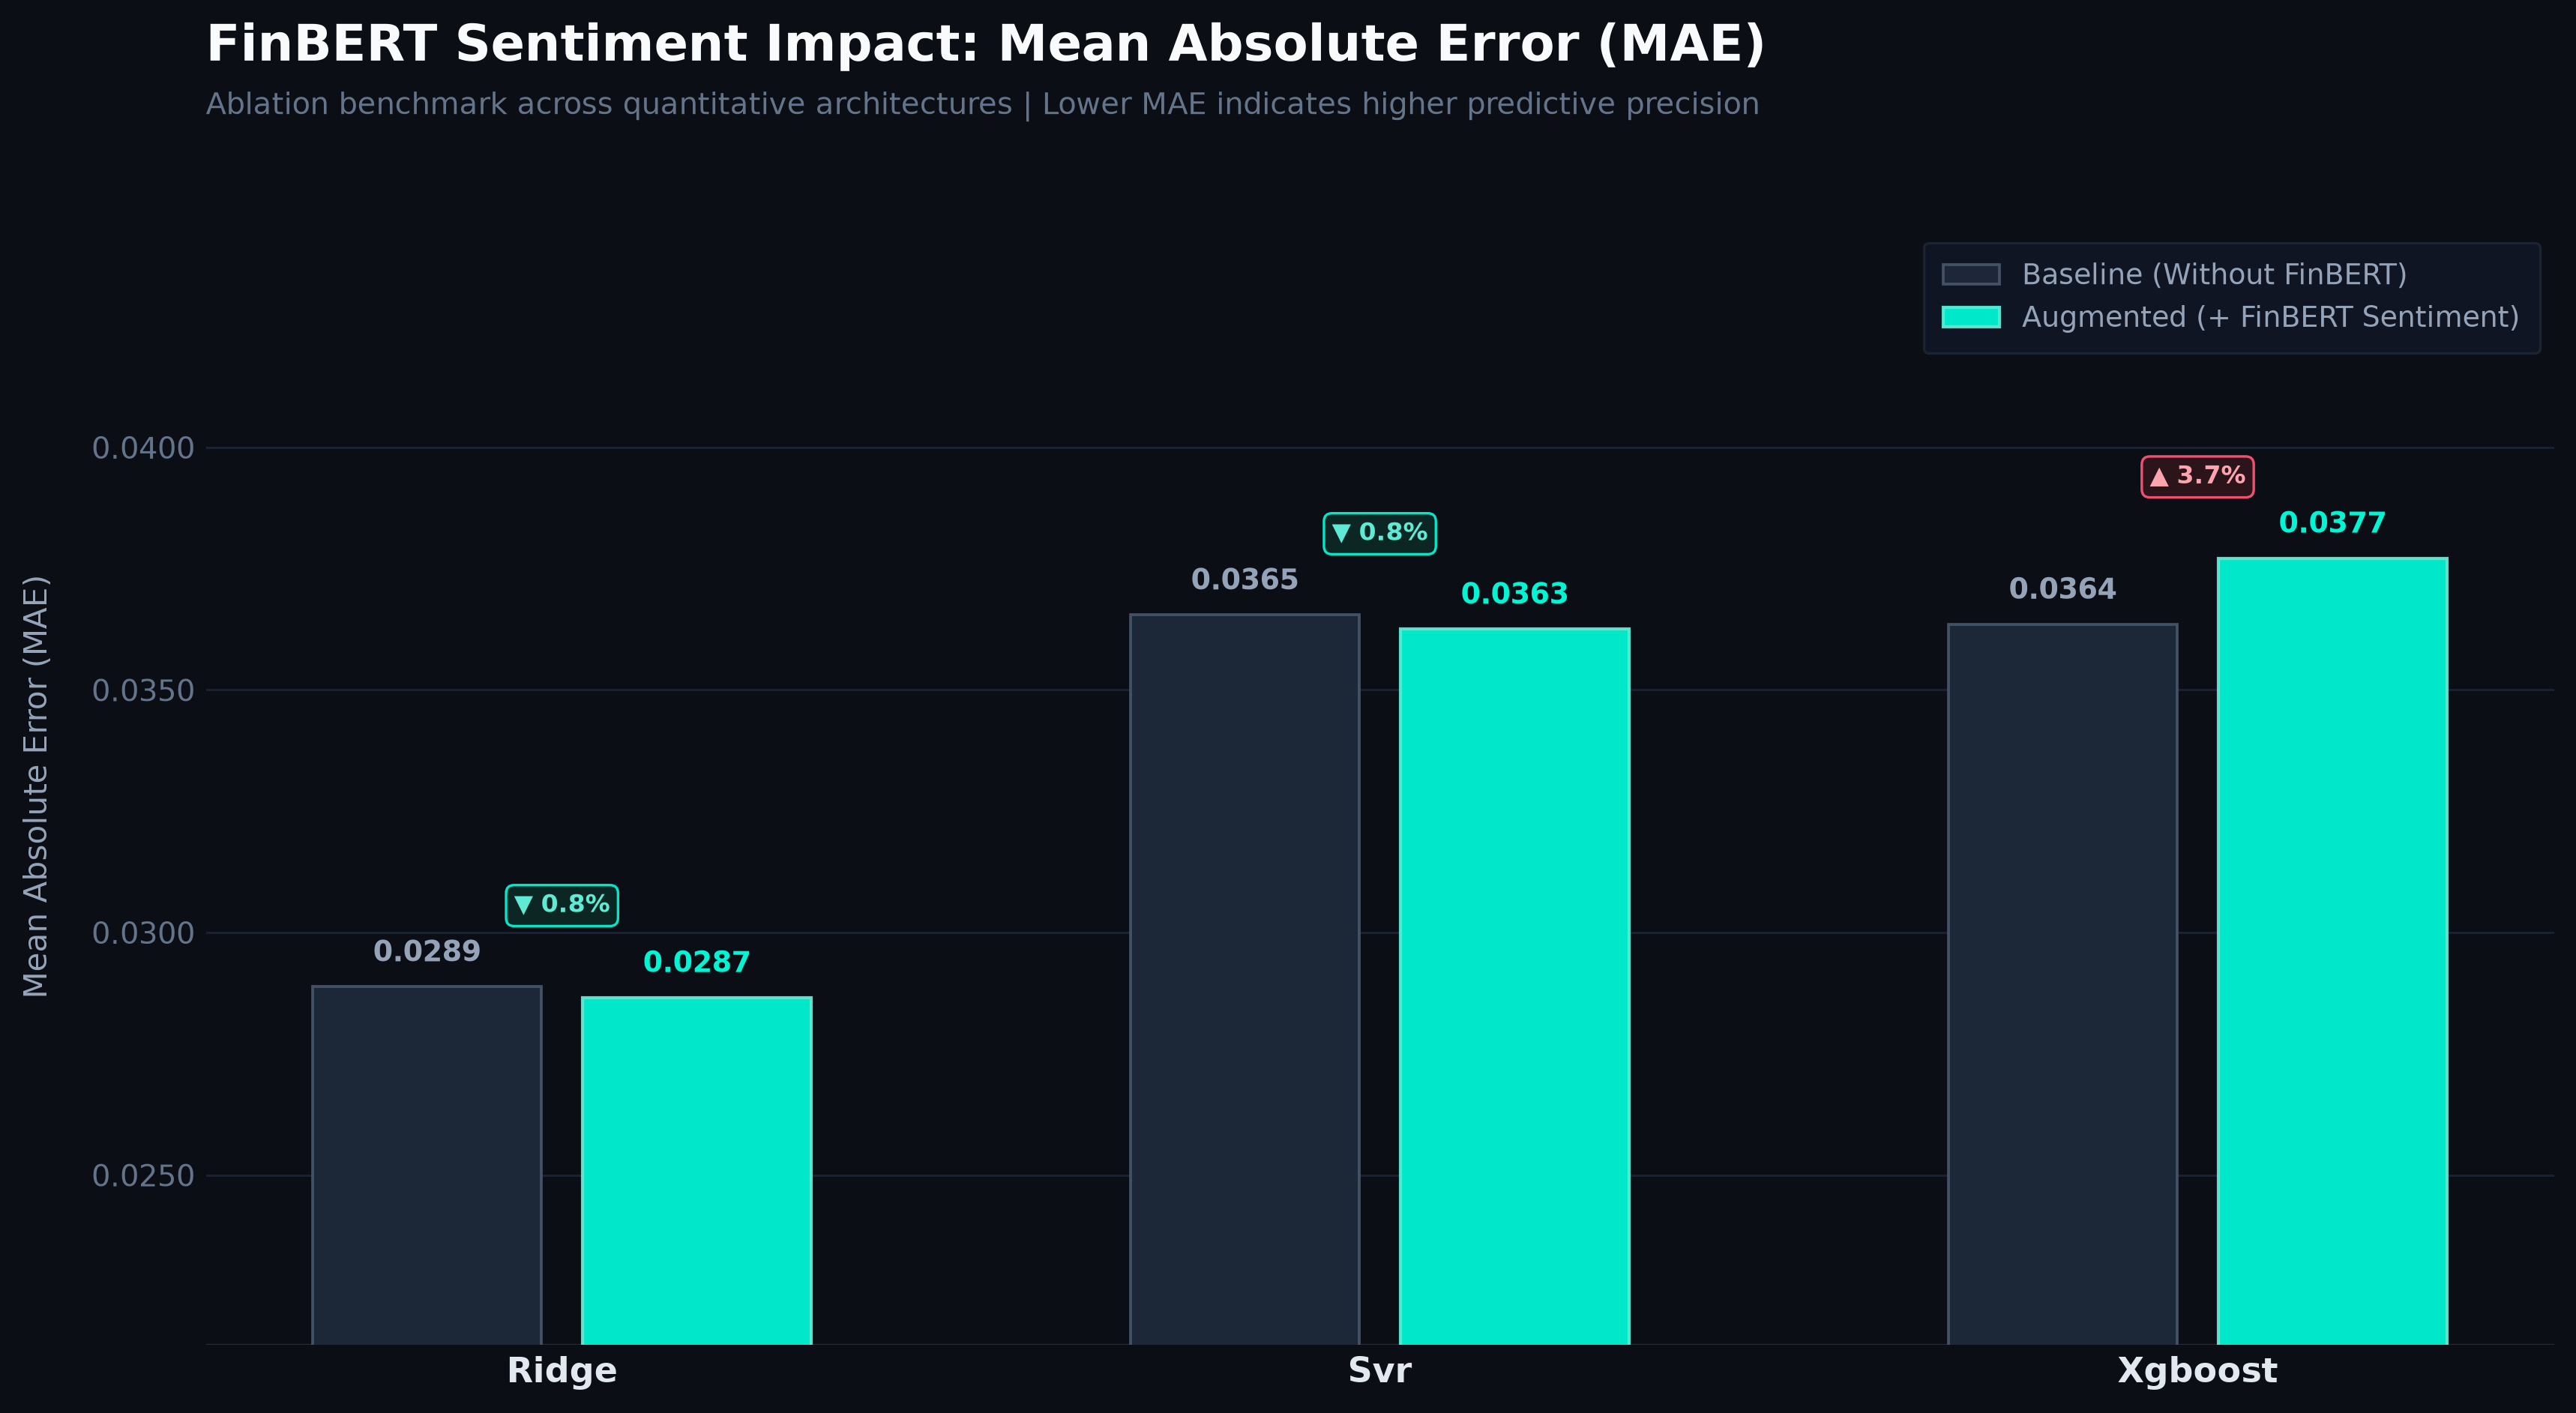

✔ Modern PNG Exported: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\sentiment\finbert_sentiment_ablation_mae.png
✔ Vector PDF Exported: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\sentiment\finbert_sentiment_ablation_mae.pdf


In [65]:
# Professional comparison chart — MAE
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ------------------------------------------------------------
# 1. Executive Modern Canvas Setup
# ------------------------------------------------------------
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 6.8), dpi=300)
fig.patch.set_facecolor("#0B0E14")
ax.set_facecolor("#0B0E14")

# Data preparation
models = wide["Model"].tolist()
clean_models = [m.replace("_", " ").replace("-", " ").title() for m in models]
n_models = len(models)
x = np.arange(n_models)

# Sleeker bar sizing (Prevents giant bulky blocks)
width = 0.28
gap = 0.025

mae_without = wide["MAE_Without"].values
mae_with = wide["MAE_With"].values

# Premium Institutional Palette:
# Baseline = Slate Charcoal (#1E293B with stroke)
# FinBERT   = Vibrant Neon Mint (#00F5D4)
c_without = "#1E293B"
c_without_edge = "#475569"
c_with = "#00F5D4"
c_with_edge = "#5EEAD4"

# ------------------------------------------------------------
# 2. Sleek Dual Bars with Ambient Glow Fills
# ------------------------------------------------------------
bars1 = ax.bar(
    x - (width / 2 + gap),
    mae_without,
    width=width,
    label="Baseline (Without FinBERT)",
    color=c_without,
    edgecolor=c_without_edge,
    linewidth=0.9,
    alpha=0.95,
    zorder=3,
)

bars2 = ax.bar(
    x + (width / 2 + gap),
    mae_with,
    width=width,
    label="Augmented (+ FinBERT Sentiment)",
    color=c_with,
    edgecolor=c_with_edge,
    linewidth=1.0,
    alpha=0.95,
    zorder=3,
)

# ------------------------------------------------------------
# 3. Precision Tags & Floating Delta Badges
# ------------------------------------------------------------
min_val = min(np.min(mae_without), np.min(mae_with))
max_val = max(np.max(mae_without), np.max(mae_with))

for i in range(n_models):
    b1_h = bars1[i].get_height()
    b2_h = bars2[i].get_height()

    # Floating Value Labels
    ax.annotate(
        f"{b1_h:.4f}",
        xy=(bars1[i].get_x() + bars1[i].get_width() / 2, b1_h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="semibold",
        color="#94A3B8",
        zorder=5,
    )

    ax.annotate(
        f"{b2_h:.4f}",
        xy=(bars2[i].get_x() + bars2[i].get_width() / 2, b2_h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#00F5D4",
        zorder=5,
    )

    # Clean Delta Badge (% Diff)
    pct_diff = ((b2_h - b1_h) / b1_h) * 100
    improved = pct_diff < 0
    delta_text = f"{'▼' if improved else '▲'} {abs(pct_diff):.1f}%"
    
    badge_bg = "#0D2825" if improved else "#2D151B"
    badge_border = "#00F5D4" if improved else "#FF5376"
    badge_text_color = "#5EEAD4" if improved else "#FDA4AF"

    ax.annotate(
        delta_text,
        xy=(x[i], max(b1_h, b2_h)),
        xytext=(0, 22),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color=badge_text_color,
        bbox=dict(
            boxstyle="round,pad=0.32",
            fc=badge_bg,
            ec=badge_border,
            lw=0.8,
            alpha=0.95,
        ),
        zorder=6,
    )

# ------------------------------------------------------------
# 4. Typography & Minimal Visual Hierarchy
# ------------------------------------------------------------
fig.text(
    0.08,
    0.96,
    "FinBERT Sentiment Impact: Mean Absolute Error (MAE)",
    fontsize=16,
    fontweight="bold",
    color="#F8FAFC",
    ha="left",
)
fig.text(
    0.08,
    0.925,
    "Ablation benchmark across quantitative architectures | Lower MAE indicates higher predictive precision",
    fontsize=9.5,
    color="#64748B",
    ha="left",
)

# ------------------------------------------------------------
# 5. Gridlines, Dynamic Zoom & Spines
# ------------------------------------------------------------
# Dynamic floor taaki chart me empty dead space na rahe
y_floor = max(0, min_val * 0.75)
ax.set_ylim(y_floor, max_val * 1.18)

ax.grid(
    True,
    which="major",
    axis="y",
    color="#1E293B",
    linestyle="-",
    linewidth=0.7,
    alpha=0.8,
)
for spine in ax.spines.values():
    spine.set_visible(False)

# Bottom hairline divider
ax.axhline(y_floor, color="#334155", linewidth=0.8, alpha=0.6)

ax.tick_params(axis="both", which="both", colors="#64748B", labelsize=9.5, length=0)
ax.set_ylabel("Mean Absolute Error (MAE)", color="#94A3B8", fontsize=10, labelpad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

ax.set_xticks(x)
ax.set_xticklabels(
    clean_models,
    ha="center",
    fontsize=11,
    fontweight="semibold",
    color="#E2E8F0",
)

# ------------------------------------------------------------
# 6. Sleek Legend
# ------------------------------------------------------------
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#111827",
    edgecolor="#1F2937",
    fontsize=9,
    labelcolor="#94A3B8",
    borderpad=0.7,
)
legend.get_frame().set_linewidth(0.8)

# ------------------------------------------------------------
# 7. Artifact Export
# ------------------------------------------------------------
plt.subplots_adjust(top=0.85, bottom=0.12, left=0.08, right=0.95)

RESULTS_DIR = Path(globals().get("RESULTS_DIR", "results/deep_learning"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

png_path = RESULTS_DIR / "finbert_sentiment_ablation_mae.png"
pdf_path = RESULTS_DIR / "finbert_sentiment_ablation_mae.pdf"

plt.savefig(png_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.savefig(pdf_path, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")

plt.show()
plt.close()

print(f"✔ Modern PNG Exported: {png_path.resolve()}")
print(f"✔ Vector PDF Exported: {pdf_path.resolve()}")